In [1]:
from jax import config
config.update("jax_platform_name", "cpu")
from functools import partial

import numpy as np
from jax import grad, jit, lax, nn
from jax import numpy as jnp
from jax import random, value_and_grad, vmap
from jax.example_libraries import optimizers
from matplotlib import pyplot as plt
from tqdm import tqdm
import pandas as pd

from jwave import FourierSeries
from jwave.acoustics import simulate_wave_propagation
from jwave.geometry import (
    Domain,
    Medium,
    Sensors,
    Sources,
    TimeAxis,
    circ_mask,
    points_on_circle,
)
from jwave.signal_processing import apply_ramp, gaussian_window, smooth

W0000 00:00:1781861874.217504 11145080 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1781861874.242097 11145080 service.cc:145] XLA service 0x60000372e800 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781861874.242270 11145080 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1781861874.244589 11145080 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1781861874.244611 11145080 mps_client.cc:384] XLA backend will use up to 26800209920 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M1 Pro


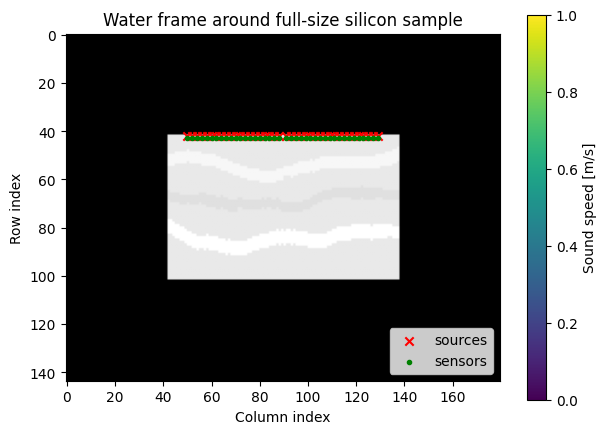

dt = 1.098e-10 s
Total simulation time = 0.329 µs
sample_top: 42
source_row: 42
sensor_row: 43
speed at source row: 8433.0
speed at sensor row: 8433.0
water_speed: 1480.0
si_speed: 8433.0


In [2]:
# Settings
scale_factor = 20

# Silicon sample size
# sample_N = (60, 96), dx = 5 µm
# Physical size = 300 µm × 480 µm
sample_N = (60, 96)
dx = (5e-6, 5e-6)

# Water frame thickness around all faces of the sample
# About 1/3 of the sample height: 128 / 3 ≈ 42 cells
#water_cells = sample_N[0] // 3

water_cells = 42
# Full simulation domain = water frame + original silicon sample
N = (
    sample_N[0] + 2 * water_cells,
    sample_N[1] + 2 * water_cells,
)

cfl = 0.2
num_sources = 40
source_freq = 1e6 * 1 * scale_factor
# source_mag = 1.3e-5
source_mag = 800.0

random_seed = random.PRNGKey(42)

# Define domain
domain = Domain(N, dx)


# ============================================================
# Define medium: water frame around full-size silicon sample
# ============================================================

water_speed = 1480.0   # m/s, approximate speed of sound in water
si_speed = 8433.0      # m/s, silicon-like speed from your original code

# Silicon sample location inside the larger water domain
sample_top = water_cells
sample_left = water_cells
sample_bottom = sample_top + sample_N[0]
sample_right = sample_left + sample_N[1]

# Start with water everywhere
sound_speed = water_speed * jnp.ones(N)

# Create a silicon sample mask
# 0 = water
# 1 = silicon sample
sample_mask = jnp.zeros(N)
sample_mask = sample_mask.at[
    sample_top:sample_bottom,
    sample_left:sample_right
].set(1.0)

# Put silicon speed inside the sample region
sound_speed = sound_speed * (1.0 - sample_mask) + si_speed * sample_mask



# ============================================================
# 3-BAND REALISTIC TECTONIC GEOMETRY EXPERIMENT
# ============================================================
# These are the base band positions before applying tectonic waviness.
#
# The bands are intentionally fewer than the benchmark cases because
# realistic irregular geometry is harder than perfectly horizontal bands.
#
# Band 1: fast layer
# Band 2: slow layer
# Band 3: fast layer
# ============================================================

layer_specs = [
    # row_start_fraction, row_end_fraction, velocity_contrast
    (0.18, 0.25,  0.05),   # Band 1: +5% fast layer
    (0.42, 0.49, -0.03),   # Band 2: -3% slow layer
    (0.68, 0.78,  0.08),   # Band 3: +8% fast layer
]

# ============================================================
# REALISTIC TECTONIC-STYLE BAND GEOMETRY
# Wavy, laterally variable, imperfect bands
# ============================================================
# This replaces the old rectangular horizontal band loop.
#
# Important outputs:
#   layer_map
#   true_band_masks_from_geometry
#   tectonic_band_geometry_irregular
#
# Later, the CSV analysis should use true_band_masks_from_geometry
# instead of rebuilding rectangular masks.
# ============================================================

import numpy as np
import jax.numpy as jnp

# Reproducible geometry
rng = np.random.default_rng(42)

# ------------------------------------------------------------
# Geometry controls
# ------------------------------------------------------------
tectonic_waviness_cells = 3       # 3 cells = 15 µm waviness
thickness_jitter_cells = 1        # +/- 1 cell = +/- 5 µm thickness variation
noise_smoothing_window = 13       # smoother tectonic boundary
vertical_safety_margin_cells = 4  # keeps bands inside sample/mask-safe region

# Horizontal coordinate inside silicon sample
sample_width_cells = sample_right - sample_left
x = np.arange(sample_width_cells)
x_norm = x / max(sample_width_cells - 1, 1)

# Output maps

layer_map = jnp.zeros(N)

# Store true masks and profiles for later analysis/plotting
true_band_masks_from_geometry = {}
tectonic_band_geometry_irregular = []

def smooth_1d_noise(noise, window=13):

    """
    Smooth one-dimensional noise with a moving average.
    This makes tectonic boundaries continuous instead of pixel-random.
    """

    if window <= 1:
        return noise

    kernel = np.ones(window) / window
    padded = np.pad(noise, pad_width=window // 2, mode="edge")
    return np.convolve(padded, kernel, mode="valid")

for band_number, (z0_frac, z1_frac, contrast) in enumerate(layer_specs, start=1):

    # --------------------------------------------------------
    # Original horizontal base position
    # --------------------------------------------------------
    base_top = sample_top + int(z0_frac * sample_N[0])
    base_bottom = sample_top + int(z1_frac * sample_N[0])
    base_thickness = base_bottom - base_top

    # --------------------------------------------------------
    # Tectonic waviness: sinusoidal bending + smooth random shift
    # --------------------------------------------------------

    phase1 = rng.uniform(0, 2 * np.pi)
    phase2 = rng.uniform(0, 2 * np.pi)

    sinusoidal_shift = (
        tectonic_waviness_cells
        * np.sin(2 * np.pi * 1.0 * x_norm + phase1)
        + 0.5 * tectonic_waviness_cells
        * np.sin(2 * np.pi * 2.0 * x_norm + phase2)
    )

    random_noise = rng.normal(0.0, 1.0, size=sample_width_cells)

    smooth_noise = smooth_1d_noise(
        random_noise,
        window=noise_smoothing_window
    )

    smooth_noise = smooth_noise / (np.max(np.abs(smooth_noise)) + 1e-8)
    random_shift = 0.75 * tectonic_waviness_cells * smooth_noise
    total_shift = sinusoidal_shift + random_shift
    top_profile = base_top + np.round(total_shift).astype(int)

    # --------------------------------------------------------
    # Variable thickness
    # --------------------------------------------------------

    thickness_noise = rng.normal(0.0, 1.0, size=sample_width_cells)

    thickness_noise = smooth_1d_noise(
        thickness_noise,
        window=noise_smoothing_window
    )

    thickness_noise = thickness_noise / (
        np.max(np.abs(thickness_noise)) + 1e-8
    )

    thickness_variation = np.round(
        thickness_jitter_cells * thickness_noise
    ).astype(int)

    thickness_profile = base_thickness + thickness_variation

    # Minimum thickness = 1 cell
    thickness_profile = np.maximum(thickness_profile, 1)
    bottom_profile = top_profile + thickness_profile

    # --------------------------------------------------------
    # Clip geometry to remain inside silicon / mask-safe region
    # --------------------------------------------------------

    min_row = sample_top + vertical_safety_margin_cells
    max_row = sample_bottom - vertical_safety_margin_cells
    top_profile = np.clip(top_profile, min_row, max_row - 1)
    bottom_profile = np.clip(bottom_profile, top_profile + 1, max_row)

    # --------------------------------------------------------
    # Create band mask column-by-column
    # --------------------------------------------------------

    layer_np = np.zeros(N, dtype=np.float32)

    for local_col, global_col in enumerate(range(sample_left, sample_right)):
        z_top = top_profile[local_col]
        z_bottom = bottom_profile[local_col]
        layer_np[z_top:z_bottom, global_col] = 1.0

    # Save true irregular mask for metrics later
    layer = jnp.array(layer_np) * sample_mask
    true_band_masks_from_geometry[band_number] = np.array(layer).astype(bool)

    # Add this band to the true sound-speed model
    sound_speed = sound_speed + si_speed * contrast * layer
    layer_map = layer_map + contrast * layer

    # Store geometry information
    tectonic_band_geometry_irregular.append({
        "band_number": band_number,
        "contrast": contrast,
        "base_top_row": base_top,
        "base_bottom_row": base_bottom,
        "mean_top_row": float(np.mean(top_profile)),
        "mean_bottom_row": float(np.mean(bottom_profile)),
        "mean_thickness_cells": float(np.mean(bottom_profile - top_profile)),
        "min_thickness_cells": int(np.min(bottom_profile - top_profile)),
        "max_thickness_cells": int(np.max(bottom_profile - top_profile)),
        "top_profile_rows": top_profile,
        "bottom_profile_rows_exclusive": bottom_profile,
    })


# Convert the sound-speed map into a j-wave FourierSeries field
sound_speed = FourierSeries(jnp.expand_dims(sound_speed, -1), domain)

medium = Medium(domain=domain, sound_speed=sound_speed, pml_size=8.0)


# ============================================================
# Time axis
# ============================================================

time_axis = TimeAxis.from_medium(medium, cfl=cfl)

# Force a long time window, as in your reference figure
n_steps = 3000
time_axis = TimeAxis(dt=time_axis.dt, t_end=n_steps * time_axis.dt)
t = time_axis.to_array()


# ============================================================
# Source signal
# ============================================================

s1 = source_mag * jnp.sin(2 * jnp.pi * source_freq * t)

# Pulse position to avoid shift
center_index = 200
center_time = center_index * time_axis.dt

# Gaussian pulse width
#sigma_time = 24e-9
sigma_time = 12e-9

signal = gaussian_window(
    apply_ramp(s1, time_axis.dt, source_freq),
    t,
    center_time,
    sigma_time
)


# ============================================================
# Sources and sensors directly at the sample surface
# ============================================================

num_sensors = num_sources  # 80 sensors because num_sources = 80

# The silicon sample starts at row sample_top.
# sample_top - 1 is the last water row before the silicon.
# This places the sources and sensors directly above the sample surface,
# but still inside the surrounding water.
source_row = sample_top 
sensor_row = sample_top + 1

# Horizontally, place sources/sensors across the silicon sample width.
# We avoid the exact sample edges by using an 8-cell margin inside the sample width.
cols = jnp.linspace(
    sample_left + 8,
    sample_right - 9,
    num_sources
).round().astype(int)

source_positions = (
    jnp.full((num_sources,), source_row, dtype=int),
    cols,
)

sensors_positions = (
    jnp.full((num_sensors,), sensor_row, dtype=int),
    cols,
)

sensors = Sensors(positions=sensors_positions)


# ============================================================
# Optional: visualize the new setup
# ============================================================

plt.figure(figsize=(7, 5))
plt.imshow(medium.sound_speed.on_grid[..., 0], cmap="gray")
plt.scatter(
    source_positions[1],
    source_positions[0],
    c="r",
    marker="x",
    label="sources"
)
plt.scatter(
    sensors_positions[1],
    sensors_positions[0],
    c="g",
    marker=".",
    label="sensors"
)
plt.colorbar(label="Sound speed [m/s]")
plt.legend(loc="lower right")
plt.title("Water frame around full-size silicon sample")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()


total_time_us = n_steps * time_axis.dt * 1e6
print(f"dt = {time_axis.dt:.3e} s")
print(f"Total simulation time = {total_time_us:.3f} µs")


# ============================================================
# Optional: old circular source/sensor setup
# ============================================================

# x, y = points_on_circle(num_sources, 40, (64, 48))
# source_positions = (jnp.array(x), jnp.array(y))

# sensors_positions = (x, y)
# sensors = Sensors(positions=sensors_positions)

speed_grid = medium.sound_speed.on_grid[..., 0]

print("sample_top:", sample_top)

print("source_row:", source_row)

print("sensor_row:", sensor_row)

print("speed at source row:", float(speed_grid[int(source_row), int(cols[0])]))

print("speed at sensor row:", float(speed_grid[int(sensor_row), int(cols[0])]))

print("water_speed:", water_speed)

print("si_speed:", si_speed)

Text(0.5, 1.0, 'Source signals')

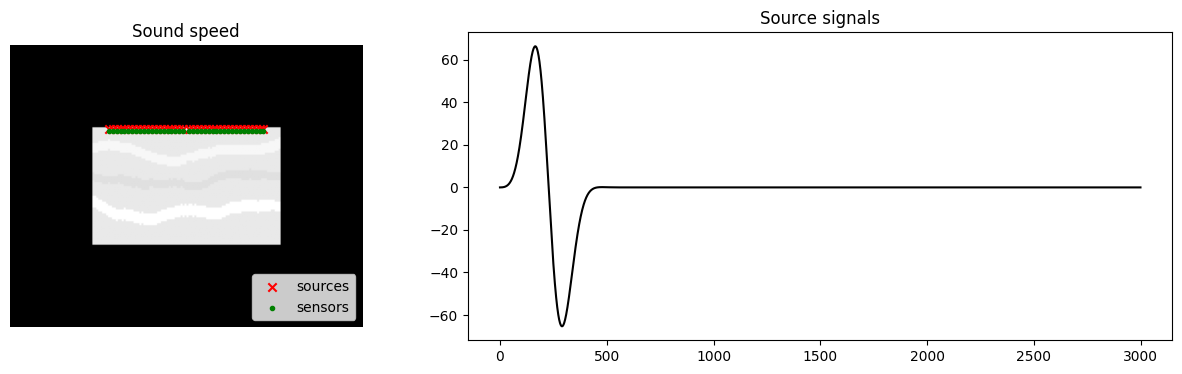

In [3]:
# Show simulation setup
fig, ax = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={"width_ratios": [1, 2]})

ax[0].imshow(medium.sound_speed.on_grid, cmap="gray")
ax[0].scatter(
    source_positions[1], source_positions[0], c="r", marker="x", label="sources"
)
ax[0].scatter(
    sensors_positions[1], sensors_positions[0], c="g", marker=".", label="sensors"
)
ax[0].legend(loc="lower right")
ax[0].set_title("Sound speed")
ax[0].axis("off")

ax[1].plot(signal, label="Source 1", c="k")
ax[1].set_title("Source signals")
#ax[1].get_yaxis().set_visible(False)



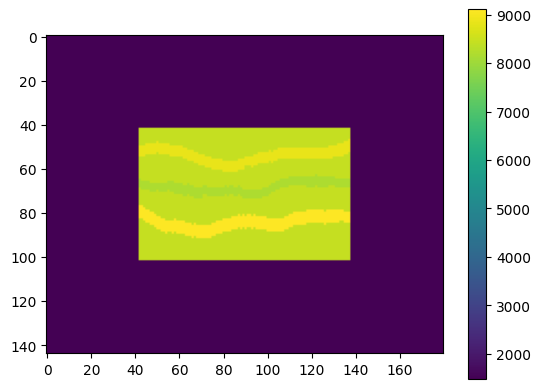

In [4]:
plt.imshow(medium.sound_speed.on_grid)
plt.colorbar()

In [5]:
src_signal = jnp.stack([signal])

# We can compile the entire function! All the constructors
# that don't depend on the inputs will be statically compiled
# and run only once.
@jit
def single_source_simulation(sound_speed, source_num):
    # Setting source
    x = lax.dynamic_slice(source_positions[0], (source_num,), (1,))
    y = lax.dynamic_slice(source_positions[1], (source_num,), (1,))
    sources = Sources((x, y), src_signal, dt=time_axis.dt, domain=domain)

    # Updating medium with the input speed of sound map
    medium = Medium(domain=domain, sound_speed=sound_speed, pml_size=8)

    # Run simulations
    # rf_signals = simulate_wave_propagation(
    #     medium, time_axis, sources=sources, sensors=sensors, checkpoint=True
    # )
    rf_signals = simulate_wave_propagation(
        medium, time_axis, sources=sources, sensors=sensors,
    )
    return rf_signals[..., 0]

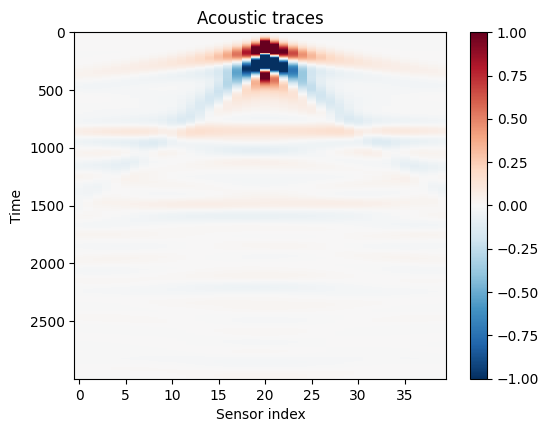

In [6]:

p = single_source_simulation(medium.sound_speed, 20)

# Visualize the acoustic traces
plt.figure(figsize=(6, 4.5))
maxval = jnp.amax(jnp.abs(p))
plt.imshow(
    p, cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest", aspect="auto"
    
)
plt.colorbar()
plt.title("Acoustic traces")
plt.xlabel("Sensor index")
plt.ylabel("Time")
plt.show()

In [7]:
print("sample_top:", sample_top)
print("sample_bottom:", sample_bottom)
print("source_row:", source_row)
print("sensor_row:", sensor_row)

if sensor_row < sample_top:
    print("Sensors are in water above the Si sample.")
elif sensor_row >= sample_bottom:
    print("Sensors are below the Si sample.")
else:
    print("Sensors are inside the Si sample.")

speed_grid = medium.sound_speed.on_grid[..., 0]

print("Speed at sensor row, first sensor:",
      speed_grid[int(sensor_row), int(cols[0])])

print("Expected water speed:", water_speed)
print("Expected Si speed:", si_speed)

sample_top: 42
sample_bottom: 102
source_row: 42
sensor_row: 43
Sensors are inside the Si sample.
Speed at sensor row, first sensor: 8433.0
Expected water speed: 1480.0
Expected Si speed: 8433.0


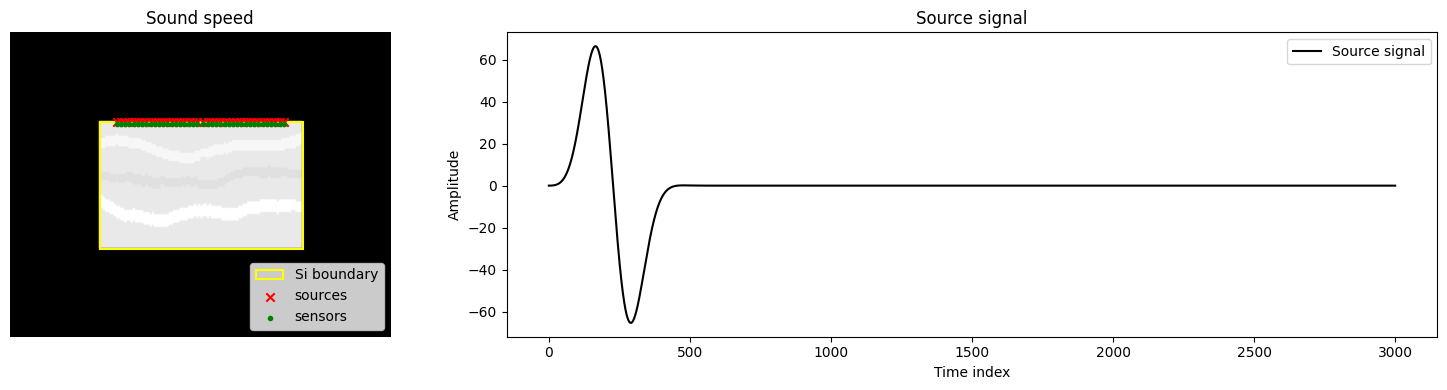

In [8]:
fig, ax = plt.subplots(
    1, 2,
    figsize=(15, 4),
    gridspec_kw={"width_ratios": [1, 2]}
)

speed_grid = medium.sound_speed.on_grid[..., 0]

ax[0].imshow(speed_grid, cmap="gray")

# Draw silicon sample boundary
rect = plt.Rectangle(
    (sample_left, sample_top),
    sample_right - sample_left,
    sample_bottom - sample_top,
    fill=False,
    edgecolor="yellow",
    linewidth=1.5,
    label="Si boundary"
)
ax[0].add_patch(rect)

ax[0].scatter(
    source_positions[1],
    source_positions[0],
    c="r",
    marker="x",
    label="sources"
)

ax[0].scatter(
    sensors_positions[1],
    sensors_positions[0],
    c="g",
    marker=".",
    label="sensors"
)

ax[0].legend(loc="lower right")
ax[0].set_title("Sound speed")
ax[0].axis("off")

ax[1].plot(signal, label="Source signal", c="k")
ax[1].set_title("Source signal")
ax[1].set_xlabel("Time index")
ax[1].set_ylabel("Amplitude")
ax[1].legend()

plt.tight_layout()
plt.show()

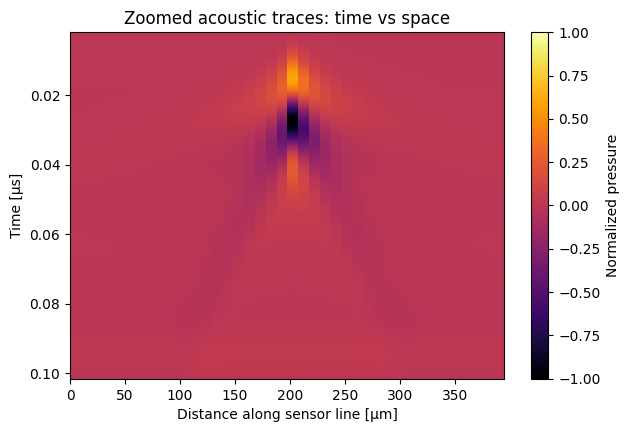

In [9]:
# ============================================================
# Prepare p
# ============================================================
p_np = np.array(p)
# Make sure shape is time × sensors
if p_np.shape[0] == num_sensors:
    p_np = p_np.T
n_time, n_sensors = p_np.shape
# Normalize
p_norm = p_np / np.nanmax(np.abs(p_np))
# Axes
time_us = np.arange(n_time) * float(time_axis.dt) * 1e6
sensor_cols = np.array(cols)
sensor_x_um = sensor_cols * dx[1] * 1e6
sensor_x_um = sensor_x_um - sensor_x_um[0]

# ============================================================
# Auto zoom to useful signal
# ============================================================
# Energy per time step
energy_t = np.max(np.abs(p_norm), axis=1)
# Find where signal is visible
zoom_threshold = 0.03
visible_idx = np.where(energy_t > zoom_threshold)[0]
if len(visible_idx) > 0:
    t0_idx = max(0, visible_idx[0] - 20)
    t1_idx = min(n_time - 1, visible_idx[-1] + 40)
else:
    t0_idx = 0
    t1_idx = n_time - 1
time_zoom_us = time_us[t0_idx:t1_idx + 1]
p_zoom = p_norm[t0_idx:t1_idx + 1, :]

# ============================================================
# Plot zoomed time-space diagram
# ============================================================
plt.figure(figsize=(7, 4.5))
plt.imshow(
    p_zoom,
    cmap="inferno",
    vmin=-1,
    vmax=1,
    interpolation="nearest",
    aspect="auto",
    extent=[
        sensor_x_um[0],
        sensor_x_um[-1],
        time_zoom_us[-1],
        time_zoom_us[0],
    ],
)
plt.colorbar(label="Normalized pressure")
plt.title("Zoomed acoustic traces: time vs space")
plt.xlabel("Distance along sensor line [µm]")
plt.ylabel("Time [µs]")
plt.show()

In [10]:
# ============================================================
# INDEPENDENT ARRIVAL PICKING + FAST/SLOW ANALYSIS CSV
# No previous arrival-analysis blocks required
# Uses: p, time_axis, cols, dx, num_sensors
# ============================================================

import os
import numpy as np
import pandas as pd
import jax.numpy as jnp
from jwave.signal_processing import analytic_signal

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

source_index = 20

# Silicon reference speed
reference_speed_m_s = 8433.0

# Arrival picker threshold: 40% of each sensor peak
arrival_fraction = 0.40

# Start searching slightly before the expected Si arrival
safety_margin_us = 0.003

# Classification tolerance
timing_tolerance_ns = 1.0

# Maximum expected speed increase from defects
# circle_1 = +5%, circle_2 = +2%, circle_3 = +3%
# Use 0.10 as conservative maximum if they overlap
max_speed_increase_fraction = 0.10

# Output folder
output_dir = "arrival_analysis_outputs"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# Convert pressure to numpy and make sure shape is [time, sensors]
# ------------------------------------------------------------

p_np = np.array(p)

if p_np.shape[0] == num_sensors:
    p_np = p_np.T

n_time, n_sensors = p_np.shape

print("p_np shape [time, sensors]:", p_np.shape)

# ------------------------------------------------------------
# Time axis
# ------------------------------------------------------------

time_us = np.arange(n_time) * float(time_axis.dt) * 1e6
time_ns = time_us * 1000.0

print("Total simulation time steps:", n_time)
print("Maximum possible time index:", n_time - 1)
print("dt [ns]:", float(time_axis.dt) * 1e9)
print("Final simulation time [ns]:", time_ns[-1])

# ------------------------------------------------------------
# Sensor positions and distance from source
# ------------------------------------------------------------

sensor_cols = np.array(cols)
sensor_x_um = sensor_cols * dx[1] * 1e6
sensor_x_um = sensor_x_um - sensor_x_um[0]

source_x_um = sensor_x_um[source_index]
distance_from_source_um = np.abs(sensor_x_um - source_x_um)

print("Source index:", source_index)
print("Source x position [um]:", source_x_um)

# ------------------------------------------------------------
# Hilbert envelope
# ------------------------------------------------------------

def hilbert_transf(signal):
    return np.abs(np.array(analytic_signal(jnp.array(signal))))

p_env = hilbert_transf(p_np)

global_max = np.nanmax(p_env)

# ------------------------------------------------------------
# Initialize arrays
# ------------------------------------------------------------

arrival_idx_full = np.full(n_sensors, np.nan)
arrival_time_full_us = np.full(n_sensors, np.nan)

expected_arrival_us_array = np.full(n_sensors, np.nan)
search_start_us_array = np.full(n_sensors, np.nan)
search_start_idx_array = np.full(n_sensors, np.nan)

arrival_residual_us = np.full(n_sensors, np.nan)
apparent_speed_m_s = np.full(n_sensors, np.nan)
speed_ratio_vs_reference = np.full(n_sensors, np.nan)

sensor_peak = np.full(n_sensors, np.nan)
sensor_peak_fraction_global = np.full(n_sensors, np.nan)

# ------------------------------------------------------------
# Arrival picking
# ------------------------------------------------------------

for s in range(n_sensors):

    trace_env = p_env[:, s]

    local_max = np.nanmax(trace_env)
    sensor_peak[s] = local_max
    sensor_peak_fraction_global[s] = local_max / global_max

    if local_max <= 0 or np.isnan(local_max):
        continue

    # Distance from source in meters
    distance_m = distance_from_source_um[s] * 1e-6

    # Expected arrival time in homogeneous Si
    expected_arrival_us = distance_m / reference_speed_m_s * 1e6
    expected_arrival_us_array[s] = expected_arrival_us

    # Start search slightly before expected arrival
    search_start_us = max(0.0, expected_arrival_us - safety_margin_us)
    search_start_us_array[s] = search_start_us

    search_start_idx = int(np.searchsorted(time_us, search_start_us))
    search_start_idx = min(search_start_idx, n_time - 1)
    search_start_idx_array[s] = search_start_idx

    # Local threshold
    local_threshold = arrival_fraction * local_max

    hits = np.where(trace_env[search_start_idx:] >= local_threshold)[0]

    if len(hits) > 0:
        arrival_idx_full[s] = search_start_idx + hits[0]
        arrival_time_full_us[s] = time_us[int(arrival_idx_full[s])]

    # Residual and apparent speed
    if not np.isnan(arrival_time_full_us[s]):

        arrival_residual_us[s] = arrival_time_full_us[s] - expected_arrival_us

        if distance_m > 0:
            apparent_speed_m_s[s] = distance_m / (arrival_time_full_us[s] * 1e-6)
            speed_ratio_vs_reference[s] = apparent_speed_m_s[s] / reference_speed_m_s

# ------------------------------------------------------------
# Convert to nanoseconds
# ------------------------------------------------------------

arrival_time_ns = arrival_time_full_us * 1000.0
expected_arrival_time_ns = expected_arrival_us_array * 1000.0
arrival_residual_ns = arrival_residual_us * 1000.0
arrival_advance_ns = expected_arrival_time_ns - arrival_time_ns

search_start_time_ns = search_start_us_array * 1000.0

# ------------------------------------------------------------
# Percent changes
# ------------------------------------------------------------

# arrival_residual_percent = (
#     100.0 * arrival_residual_ns / expected_arrival_time_ns
# )

# arrival_advance_percent = (
#     100.0 * arrival_advance_ns / expected_arrival_time_ns
# )

# # Avoid division by zero at source sensor
# arrival_residual_percent[expected_arrival_time_ns == 0] = np.nan
# arrival_advance_percent[expected_arrival_time_ns == 0] = np.nan


# ------------------------------------------------------------
# Percent changes
# Avoid division by zero at the source sensor
# ------------------------------------------------------------

arrival_residual_percent = np.full(n_sensors, np.nan)
arrival_advance_percent = np.full(n_sensors, np.nan)

valid_expected = expected_arrival_time_ns > 0

arrival_residual_percent[valid_expected] = (
    100.0
    * arrival_residual_ns[valid_expected]
    / expected_arrival_time_ns[valid_expected]
)

arrival_advance_percent[valid_expected] = (
    100.0
    * arrival_advance_ns[valid_expected]
    / expected_arrival_time_ns[valid_expected]
)


# ------------------------------------------------------------
# Behavior classification
# Positive advance = faster than expected
# ------------------------------------------------------------

arrival_behavior = np.full(n_sensors, "no_detection", dtype=object)

for s in range(n_sensors):

    if np.isnan(arrival_time_ns[s]):
        arrival_behavior[s] = "no_detection"

    elif arrival_advance_ns[s] > timing_tolerance_ns:
        arrival_behavior[s] = "faster_than_expected"

    elif arrival_advance_ns[s] < -timing_tolerance_ns:
        arrival_behavior[s] = "slower_than_expected"

    else:
        arrival_behavior[s] = "as_expected"

# ------------------------------------------------------------
# Physical diagnostic without t0_source correction
# ------------------------------------------------------------

max_possible_speed_m_s = reference_speed_m_s * (1.0 + max_speed_increase_fraction)

distance_m_all = distance_from_source_um * 1e-6

travel_time_reference_ns = distance_m_all / reference_speed_m_s * 1e9
travel_time_fastest_ns = distance_m_all / max_possible_speed_m_s * 1e9

max_possible_advance_ns = travel_time_reference_ns - travel_time_fastest_ns

advance_excess_ns = arrival_advance_ns - max_possible_advance_ns

advance_is_physically_suspicious = advance_excess_ns > 1.0

# ------------------------------------------------------------
# Create final DataFrame
# ------------------------------------------------------------

arrival_table_direct_first_all_sensors = pd.DataFrame({
    "arrival_type": "direct_first_arrival",
    "sensor_index": np.arange(n_sensors),
    "x_position_um": sensor_x_um,
    "distance_from_source_um": distance_from_source_um,

    # Detected arrival
    "arrival_time_us": arrival_time_full_us,
    "arrival_time_ns": arrival_time_ns,
    "arrival_sample_index": arrival_idx_full,

    # Expected arrival in homogeneous Si
    "expected_arrival_time_us": expected_arrival_us_array,
    "expected_arrival_time_ns": expected_arrival_time_ns,

    # Residual: detected - expected
    # Negative residual = faster than expected
    "arrival_residual_us": arrival_residual_us,
    "arrival_residual_ns": arrival_residual_ns,
    "arrival_residual_percent": arrival_residual_percent,

    # Advance: expected - detected
    # Positive advance = faster than expected
    "arrival_advance_ns": arrival_advance_ns,
    "arrival_advance_percent": arrival_advance_percent,

    # Search-window debug
    "search_start_time_us": search_start_us_array,
    "search_start_time_ns": search_start_time_ns,
    "search_start_index": search_start_idx_array,

    # Speed interpretation
    "reference_speed_m_s": reference_speed_m_s,
    "apparent_speed_m_s": apparent_speed_m_s,
    "speed_ratio_vs_reference": speed_ratio_vs_reference,
    "arrival_behavior": arrival_behavior,

    # Physical diagnostic
    "max_speed_increase_fraction": max_speed_increase_fraction,
    "max_possible_speed_m_s": max_possible_speed_m_s,
    "max_possible_advance_ns": max_possible_advance_ns,
    "advance_excess_ns": advance_excess_ns,
    "advance_is_physically_suspicious": advance_is_physically_suspicious,

    # Picker and signal quality
    "threshold_fraction_of_sensor_peak": arrival_fraction,
    "timing_tolerance_ns": timing_tolerance_ns,
    "sensor_peak_envelope": sensor_peak,
    "sensor_peak_normalized_to_global_max": sensor_peak_fraction_global,
})

# ------------------------------------------------------------
# Save full CSV
# ------------------------------------------------------------

full_csv_path = os.path.join(
    output_dir,
    "arrival_table_direct_first_all_sensors_final_no_t0_correction.csv"
)

arrival_table_direct_first_all_sensors.to_csv(full_csv_path, index=False)

# ------------------------------------------------------------
# Save sorted table: strongest advances first
# ------------------------------------------------------------

advance_sorted_table = arrival_table_direct_first_all_sensors.sort_values(
    "arrival_advance_ns",
    ascending=False
)[[
    "sensor_index",
    "x_position_um",
    "distance_from_source_um",
    "arrival_time_ns",
    "expected_arrival_time_ns",
    "arrival_advance_ns",
    "arrival_advance_percent",
    "max_possible_advance_ns",
    "advance_excess_ns",
    "advance_is_physically_suspicious",
    "speed_ratio_vs_reference",
    "arrival_behavior"
]]

sorted_csv_path = os.path.join(
    output_dir,
    "arrival_advance_sorted_no_t0_correction.csv"
)

advance_sorted_table.to_csv(sorted_csv_path, index=False)

# ------------------------------------------------------------
# Display and summary
# ------------------------------------------------------------

display(arrival_table_direct_first_all_sensors)
display(advance_sorted_table)

print("Saved full CSV:", full_csv_path)
print("Saved sorted CSV:", sorted_csv_path)
print("Total sensors:", n_sensors)
print("Valid arrivals:", np.sum(~np.isnan(arrival_time_ns)))
print("Missing arrivals:", np.sum(np.isnan(arrival_time_ns)))
print("Faster than expected:", np.sum(arrival_behavior == "faster_than_expected"))
print("As expected:", np.sum(arrival_behavior == "as_expected"))
print("Slower than expected:", np.sum(arrival_behavior == "slower_than_expected"))
print("Physically suspicious:", np.sum(advance_is_physically_suspicious))

p_np shape [time, sensors]: (3000, 40)
Total simulation time steps: 3000
Maximum possible time index: 2999
dt [ns]: 0.10979793463317122
Final simulation time [ns]: 329.2840059648805
Source index: 20
Source x position [um]: 205.00000000000006


,arrival_type,sensor_index,x_position_um,distance_from_source_um,arrival_time_us,arrival_time_ns,arrival_sample_index,expected_arrival_time_us,expected_arrival_time_ns,arrival_residual_us,...,arrival_behavior,max_speed_increase_fraction,max_possible_speed_m_s,max_possible_advance_ns,advance_excess_ns,advance_is_physically_suspicious,threshold_fraction_of_sensor_peak,timing_tolerance_ns,sensor_peak_envelope,sensor_peak_normalized_to_global_max
0,direct_first_arrival,0,0.0,205.0,0.021411,21.410597,195.0,0.024309,24.309261,-0.002899,...,faster_than_expected,0.1,9276.3,2.209933,0.688731,False,0.4,1.0,0.227544,0.051036
1,direct_first_arrival,1,10.0,195.0,0.020203,20.202820,184.0,0.023123,23.123444,-0.002921,...,faster_than_expected,0.1,9276.3,2.102131,0.818492,False,0.4,1.0,0.245813,0.055134
2,direct_first_arrival,2,20.0,185.0,0.018995,18.995043,173.0,0.021938,21.937626,-0.002943,...,faster_than_expected,0.1,9276.3,1.994330,0.948254,False,0.4,1.0,0.239206,0.053652
3,direct_first_arrival,3,30.0,175.0,0.017787,17.787265,162.0,0.020752,20.751808,-0.002965,...,faster_than_expected,0.1,9276.3,1.886528,1.078015,True,0.4,1.0,0.257364,0.057724
4,direct_first_arrival,4,40.0,165.0,0.016579,16.579488,151.0,0.019566,19.565991,-0.002987,...,faster_than_expected,0.1,9276.3,1.778726,1.207776,True,0.4,1.0,0.262084,0.058783
5,direct_first_arrival,5,50.0,155.0,0.015482,15.481509,141.0,0.018380,18.380173,-0.002899,...,faster_than_expected,0.1,9276.3,1.670925,1.227740,True,0.4,1.0,0.284014,0.063702
6,direct_first_arrival,6,60.0,145.0,0.014274,14.273732,130.0,0.017194,17.194356,-0.002921,...,faster_than_expected,0.1,9276.3,1.563123,1.357501,True,0.4,1.0,0.295510,0.066280
7,direct_first_arrival,7,70.0,135.0,0.013066,13.065954,119.0,0.016009,16.008538,-0.002943,...,faster_than_expected,0.1,9276.3,1.455322,1.487262,True,0.4,1.0,0.325856,0.073087
8,direct_first_arrival,8,80.0,125.0,0.012188,12.187571,111.0,0.014823,14.822720,-0.002635,...,faster_than_expected,0.1,9276.3,1.347520,1.287629,True,0.4,1.0,0.341395,0.076572
9,direct_first_arrival,9,90.0,115.0,0.010760,10.760198,98.0,0.013637,13.636903,-0.002877,...,faster_than_expected,0.1,9276.3,1.239718,1.636987,True,0.4,1.0,0.386739,0.086742


,sensor_index,x_position_um,distance_from_source_um,arrival_time_ns,expected_arrival_time_ns,arrival_advance_ns,arrival_advance_percent,max_possible_advance_ns,advance_excess_ns,advance_is_physically_suspicious,speed_ratio_vs_reference,arrival_behavior
34,34,345.0,140.0,13.614944,16.601447,2.986503,17.989413,1.509222,1.477280,True,1.219355,faster_than_expected
4,4,40.0,165.0,16.579488,19.565991,2.986503,15.263743,1.778726,1.207776,True,1.180132,faster_than_expected
39,39,395.0,190.0,19.544032,22.530535,2.986502,13.255355,2.048230,0.938272,False,1.152809,faster_than_expected
35,35,355.0,150.0,14.822721,17.787264,2.964543,16.666662,1.617024,1.347519,True,1.200000,faster_than_expected
3,3,30.0,175.0,17.787265,20.751808,2.964543,14.285709,1.886528,1.078015,True,1.166667,faster_than_expected
7,7,70.0,135.0,13.065954,16.008538,2.942584,18.381339,1.455322,1.487262,True,1.225210,faster_than_expected
36,36,365.0,160.0,16.030498,18.973082,2.942583,15.509254,1.724826,1.217758,True,1.183562,faster_than_expected
2,2,20.0,185.0,18.995043,21.937626,2.942583,13.413408,1.994330,0.948254,False,1.154913,faster_than_expected
6,6,60.0,145.0,14.273732,17.194356,2.920624,16.985946,1.563123,1.357501,True,1.204615,faster_than_expected
37,37,375.0,170.0,17.238276,20.158900,2.920624,14.488012,1.832627,1.087997,True,1.169427,faster_than_expected


Saved full CSV: arrival_analysis_outputs/arrival_table_direct_first_all_sensors_final_no_t0_correction.csv
Saved sorted CSV: arrival_analysis_outputs/arrival_advance_sorted_no_t0_correction.csv
Total sensors: 40
Valid arrivals: 40
Missing arrivals: 0
Faster than expected: 19
As expected: 4
Slower than expected: 17
Physically suspicious: 12


In [11]:
batch_simulations = vmap(single_source_simulation, in_axes=(None, 0))
p_data = batch_simulations(medium.sound_speed, jnp.arange(num_sources))
print(f"Size of data [Source idx, Time, Sensor idx]: {p_data.shape}")

Size of data [Source idx, Time, Sensor idx]: (40, 3000, 40)


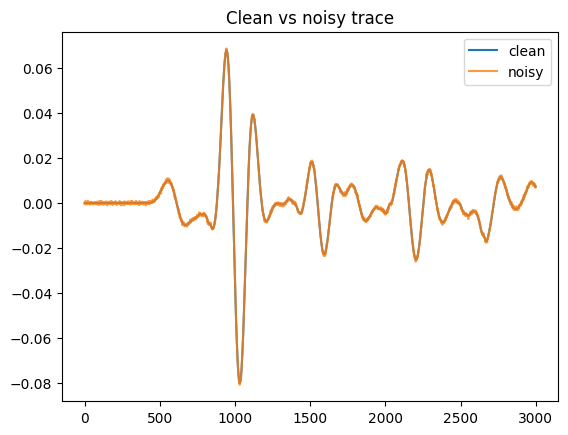

In [12]:
# ============================================================
# ADD PER-TRACE RELATIVE NOISE + CLEAN/NOISY COMPARISON
# Old variable names preserved
# ============================================================

p_data = batch_simulations(medium.sound_speed, jnp.arange(num_sources))

noise_level = 0.005

p_clean = np.array(p_data)

trace_scale = np.max(np.abs(p_clean), axis=1, keepdims=True)
trace_scale[trace_scale == 0] = 1.0

noise = np.random.normal(size=p_clean.shape) * noise_level * trace_scale

p_data = jnp.array(p_clean + noise)

plt.plot(p_clean[39, :, 0], label="clean")
plt.plot(p_data[39, :, 0], label="noisy", alpha=0.8)
plt.title("Clean vs noisy trace")
plt.legend()
plt.show()

In [13]:
from jaxdf.operators import compose

# ============================================================
# Background model for inversion
# Water frame + homogeneous silicon sample
# No tectonic layer in the initial model
# ============================================================

background_speed_grid = water_speed * jnp.ones(N)

background_speed_grid = background_speed_grid.at[
    sample_top:sample_bottom,
    sample_left:sample_right
].set(si_speed)

background_speed = FourierSeries(
    jnp.expand_dims(background_speed_grid, -1),
    domain
)


# ============================================================
# Inversion mask
# Only allow updates inside the silicon sample
# Keep a small margin away from sample boundaries
# ============================================================

margin = 4

mask_grid = jnp.zeros(N)

mask_grid = mask_grid.at[
    sample_top + margin : sample_bottom - margin,
    sample_left + margin : sample_right - margin
].set(1.0)

mask = FourierSeries(
    jnp.expand_dims(mask_grid, -1),
    domain
)


# ============================================================
# Sound-speed parameterization
# Allows positive and negative velocity updates
# ============================================================

max_velocity_update = 700.0  # m/s

def get_sound_speed(params):
    velocity_update = (
        max_velocity_update
        * compose(params)(jnp.tanh)
        * mask
    )

    return background_speed + velocity_update


# Initial params = 0 gives tanh(0) = 0
# Therefore initial inversion model = background_speed exactly
params = medium.sound_speed * 0.0

Initial speed outside sample:
1480.0
Initial speed inside sample:
8433.0
Expected water speed: 1480.0
Expected silicon speed: 8433.0


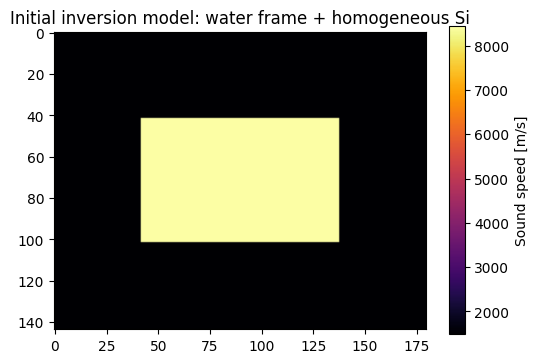

In [14]:
# ============================================================
# Verify the initial inversion model
# ============================================================

initial_sos = get_sound_speed(params).on_grid[..., 0]

print("Initial speed outside sample:")
print(float(initial_sos[0, 0]))

print("Initial speed inside sample:")
print(float(initial_sos[sample_top + 10, sample_left + 10]))

print("Expected water speed:", water_speed)
print("Expected silicon speed:", si_speed)

plt.figure(figsize=(6, 4))
plt.imshow(initial_sos, cmap="inferno")
plt.colorbar(label="Sound speed [m/s]")
plt.title("Initial inversion model: water frame + homogeneous Si")
plt.show()

In [15]:
# ============================================================
# Smoothness regularization
# Penalizes rough spatial variations in the inversion parameters
# ============================================================

regularization_weight = 1e-5
vertical_weight = 3.0
horizontal_weight = 1.0


def smoothness_regularization(params):
    p = params.on_grid[..., 0]

    vertical_diff = p[1:, :] - p[:-1, :]
    horizontal_diff = p[:, 1:] - p[:, :-1]

    reg = (
        vertical_weight * jnp.mean(vertical_diff ** 2)
        + horizontal_weight * jnp.mean(horizontal_diff ** 2)
    )

    return regularization_weight * reg


In [16]:
# ============================================================
# Optional: Penalize negative velocity updates
# Use only when you know the target anomaly should be faster
# than the background.
#
# WARNING:
# If the sample may contain voids, cracks, pores, or slow defects,
# this can hide the real defect. For void detection, set:
#     use_negative_update_penalty = False
# ============================================================

use_negative_update_penalty = False

negative_update_weight = 5e-7


def negative_update_regularization(params):
    velocity_update = (
        max_velocity_update
        * compose(params)(jnp.tanh)
        * mask
    )

    update_grid = velocity_update.on_grid[..., 0]

    # Keep only negative updates.
    # Positive updates become 0.
    negative_part = jnp.minimum(update_grid, 0.0)

    return negative_update_weight * jnp.mean(negative_part ** 2)

In [17]:
# ============================================================
# LOSS FUNCTION SELECTION
# Change only loss_name to test different losses
# ============================================================

from jwave.signal_processing import analytic_signal
from jaxdf.operators import gradient, functional


# Choose one:
# "mse"
# "envelope_mse"
# "normalized_l2"
# "global_normalized_mse"
# "trace_normalized_mse"
# "cross_correlation"
# "tracewise_cross_correlation"
# "log_envelope"
# "phase"
# "time_derivative_mse"
# "wasserstein_1d"
# "amplitude_envelope"
# "hybrid"

loss_name = "amplitude_envelope"


# ============================================================
# Helper functions
# ============================================================

def hilbert_transf(signal, noise=0.2):
    """
    Original envelope transform used in your code.
    """
    x = jnp.abs(analytic_signal(signal))
    return x


def safe_norm(x, eps=1e-8):
    return jnp.sqrt(jnp.sum(x ** 2) + eps)


def normalize_global(data, eps=1e-8):
    return data / (jnp.max(jnp.abs(data)) + eps)


def normalize_traces(data, eps=1e-8):
    """
    Normalize along time axis.

    In your code, p seems to have shape:
        time, sensors, maybe components

    So time is probably axis=0.
    """
    return data / (jnp.max(jnp.abs(data), axis=0, keepdims=True) + eps)


def time_derivative(data, dt):
    """
    Time derivative along time axis.
    """
    return (data[1:, ...] - data[:-1, ...]) / dt


# ============================================================
# Individual loss functions
# ============================================================

def mse_loss(predicted_data, observed_data, eps=1e-8):
    residual = predicted_data - observed_data
    return 0.5 * jnp.mean(residual ** 2)


def envelope_mse_loss(predicted_data, observed_data, eps=1e-8):
    """
    This is closest to your current loss.
    """
    predicted_env = hilbert_transf(predicted_data)
    observed_env = hilbert_transf(observed_data)

    residual = predicted_env - observed_env

    return 0.5 * jnp.mean(residual ** 2)


def normalized_l2_loss(predicted_data, observed_data, eps=1e-8):
    residual = predicted_data - observed_data

    numerator = jnp.sum(residual ** 2)
    denominator = jnp.sum(observed_data ** 2) + eps

    return 0.5 * numerator / denominator


def global_normalized_mse_loss(predicted_data, observed_data, eps=1e-8):
    predicted_n = normalize_global(predicted_data, eps)
    observed_n = normalize_global(observed_data, eps)

    residual = predicted_n - observed_n

    return 0.5 * jnp.mean(residual ** 2)


def trace_normalized_mse_loss(predicted_data, observed_data, eps=1e-8):
    predicted_n = normalize_traces(predicted_data, eps)
    observed_n = normalize_traces(observed_data, eps)

    residual = predicted_n - observed_n

    return 0.5 * jnp.mean(residual ** 2)


def cross_correlation_loss(predicted_data, observed_data, eps=1e-8):
    predicted_flat = predicted_data.reshape(-1)
    observed_flat = observed_data.reshape(-1)

    predicted_flat = predicted_flat - jnp.mean(predicted_flat)
    observed_flat = observed_flat - jnp.mean(observed_flat)

    numerator = jnp.sum(predicted_flat * observed_flat)

    denominator = (
        safe_norm(predicted_flat, eps)
        * safe_norm(observed_flat, eps)
    )

    corr = numerator / denominator

    return 1.0 - corr


def tracewise_cross_correlation_loss(predicted_data, observed_data, eps=1e-8):
    """
    Trace-wise correlation.

    Assumes time axis is axis=0.
    """
    predicted_zm = predicted_data - jnp.mean(
        predicted_data,
        axis=0,
        keepdims=True
    )

    observed_zm = observed_data - jnp.mean(
        observed_data,
        axis=0,
        keepdims=True
    )

    numerator = jnp.sum(predicted_zm * observed_zm, axis=0)

    denominator = (
        jnp.sqrt(jnp.sum(predicted_zm ** 2, axis=0) + eps)
        * jnp.sqrt(jnp.sum(observed_zm ** 2, axis=0) + eps)
    )

    corr_per_trace = numerator / denominator

    return 1.0 - jnp.mean(corr_per_trace)


def log_envelope_loss(predicted_data, observed_data, eps=1e-8):
    predicted_env = hilbert_transf(predicted_data)
    observed_env = hilbert_transf(observed_data)

    predicted_log = jnp.log(predicted_env + eps)
    observed_log = jnp.log(observed_env + eps)

    residual = predicted_log - observed_log

    return 0.5 * jnp.mean(residual ** 2)


def phase_loss(predicted_data, observed_data, eps=1e-8):
    predicted_analytic = analytic_signal(predicted_data)
    observed_analytic = analytic_signal(observed_data)

    predicted_phase = jnp.angle(predicted_analytic)
    observed_phase = jnp.angle(observed_analytic)

    phase_difference = predicted_phase - observed_phase

    phase_residual = jnp.angle(jnp.exp(1j * phase_difference))

    return 0.5 * jnp.mean(phase_residual ** 2)


def time_derivative_mse_loss(predicted_data, observed_data, eps=1e-8):
    predicted_dt = time_derivative(predicted_data, time_axis.dt)
    observed_dt = time_derivative(observed_data, time_axis.dt)

    residual = predicted_dt - observed_dt

    return 0.5 * jnp.mean(residual ** 2)


def positive_normalized_density(data, eps=1e-8):
    density = data ** 2
    density = density + eps

    density = density / jnp.sum(
        density,
        axis=0,
        keepdims=True
    )

    return density


def wasserstein_1d_loss(predicted_data, observed_data, eps=1e-8):
    predicted_density = positive_normalized_density(predicted_data, eps)
    observed_density = positive_normalized_density(observed_data, eps)

    predicted_cdf = jnp.cumsum(predicted_density, axis=0)
    observed_cdf = jnp.cumsum(observed_density, axis=0)

    residual = predicted_cdf - observed_cdf

    return jnp.mean(jnp.abs(residual))


def amplitude_envelope_loss(predicted_data, observed_data, eps=1e-8):
    alpha = 0.7

    waveform_part = trace_normalized_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    envelope_part = envelope_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    return alpha * waveform_part + (1.0 - alpha) * envelope_part


def hybrid_fwi_loss(predicted_data, observed_data, eps=1e-8):
    w_mse = 0.4
    w_corr = 0.3
    w_env = 0.2
    w_deriv = 0.1

    loss_mse = trace_normalized_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    loss_corr = tracewise_cross_correlation_loss(
        predicted_data,
        observed_data,
        eps
    )

    loss_env = envelope_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    loss_deriv = time_derivative_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    return (
        w_mse * loss_mse
        + w_corr * loss_corr
        + w_env * loss_env
        + w_deriv * loss_deriv
    )


# ============================================================
# Loss selector
# ============================================================

def selected_loss(predicted_data, observed_data):
    if loss_name == "mse":
        return mse_loss(predicted_data, observed_data)

    elif loss_name == "envelope_mse":
        return envelope_mse_loss(predicted_data, observed_data)

    elif loss_name == "normalized_l2":
        return normalized_l2_loss(predicted_data, observed_data)

    elif loss_name == "global_normalized_mse":
        return global_normalized_mse_loss(predicted_data, observed_data)

    elif loss_name == "trace_normalized_mse":
        return trace_normalized_mse_loss(predicted_data, observed_data)

    elif loss_name == "cross_correlation":
        return cross_correlation_loss(predicted_data, observed_data)

    elif loss_name == "tracewise_cross_correlation":
        return tracewise_cross_correlation_loss(predicted_data, observed_data)

    elif loss_name == "log_envelope":
        return log_envelope_loss(predicted_data, observed_data)

    elif loss_name == "phase":
        return phase_loss(predicted_data, observed_data)

    elif loss_name == "time_derivative_mse":
        return time_derivative_mse_loss(predicted_data, observed_data)

    elif loss_name == "wasserstein_1d":
        return wasserstein_1d_loss(predicted_data, observed_data)

    elif loss_name == "amplitude_envelope":
        return amplitude_envelope_loss(predicted_data, observed_data)

    elif loss_name == "hybrid":
        return hybrid_fwi_loss(predicted_data, observed_data)

    else:
        raise ValueError(f"Unknown loss_name: {loss_name}")


# ============================================================
# Main loss function used by value_and_grad
# ============================================================

def loss_func(params, source_num):
    c0 = get_sound_speed(params)

    predicted_data = single_source_simulation(c0, source_num)

    observed_data = p_data[source_num]

    loss = selected_loss(
        predicted_data,
        observed_data
    )
    reg_loss = smoothness_regularization(params)
    loss = loss + reg_loss
    # Optional prior: discourage negative velocity updates
    if use_negative_update_penalty:
        loss = loss + negative_update_regularization(params)
    return loss


loss_with_grad = value_and_grad(loss_func, argnums=0)

print("Using loss function:", loss_name)
print("Regularization weight:", regularization_weight)

Using loss function: amplitude_envelope
Regularization weight: 1e-05


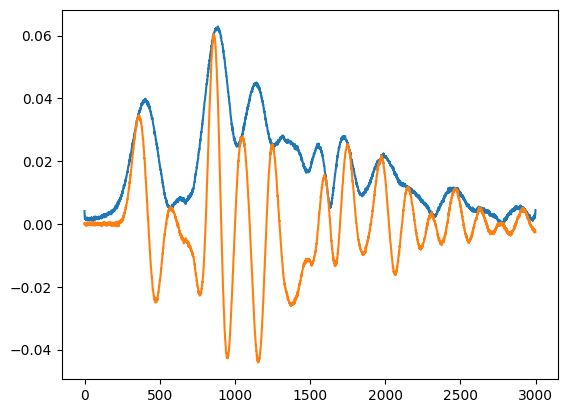

In [18]:
plt.plot(hilbert_transf(p_data[20, :, 0]))
plt.plot(p_data[20, :, 0])
plt.show()

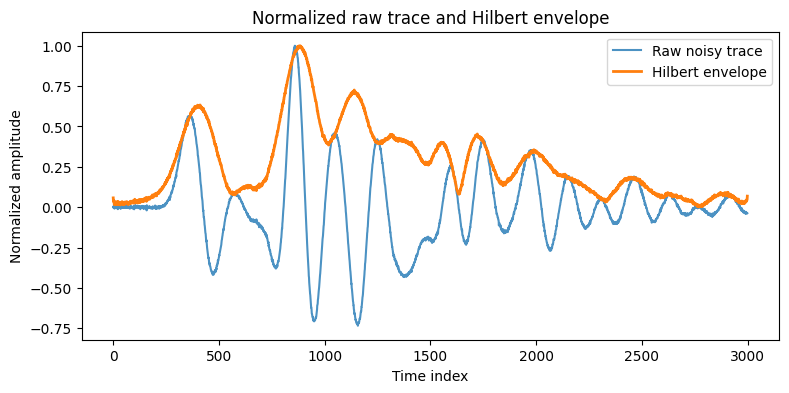

In [19]:
# ============================================================
# CHECK RAW TRACE + HILBERT ENVELOPE AFTER NOISE
# ============================================================

sensor_id = 20
source_id = 0

raw_trace = np.array(p_data[source_id, :,sensor_id])
env_trace = np.abs(np.array(analytic_signal(jnp.array(raw_trace))))

# Normalize only for visualization
raw_trace_norm = raw_trace / np.max(np.abs(raw_trace))
env_trace_norm = env_trace / np.max(env_trace)

plt.figure(figsize=(9, 4))
plt.plot(raw_trace_norm, label="Raw noisy trace", alpha=0.8)
plt.plot(env_trace_norm, label="Hilbert envelope", linewidth=2)
plt.title("Normalized raw trace and Hilbert envelope")
plt.xlabel("Time index")
plt.ylabel("Normalized amplitude")
plt.legend()
plt.show()

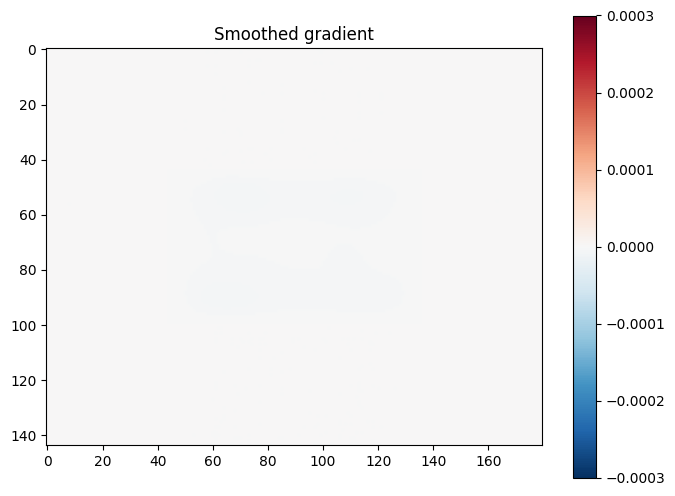

In [20]:
def smooth_fun(gradient):
    x = gradient.on_grid[..., 0]
    x = smooth(x)
    return gradient.replace_params(jnp.expand_dims(x, -1))

loss, gradient = loss_with_grad(params, source_num=10)
gradient = smooth_fun(gradient)

# Viualize
plt.figure(figsize=(8, 6))
plt.imshow(gradient.on_grid, cmap="RdBu_r", vmin=-0.0003, vmax=0.0003)
plt.title("Smoothed gradient")
plt.colorbar()
plt.show()

In [21]:
# ============================================================
# Validation loss over fixed sources
# ============================================================

validation_sources = jnp.array([0, 5, 10, 15, 20, 25, 30, 35])


def validation_loss(params):
    losses = []

    for src in validation_sources:
        loss_src = loss_func(params, int(src))
        losses.append(loss_src)

    return jnp.mean(jnp.array(losses))

In [22]:
losshistory = []
validation_losshistory = []
reconstructions = []
grad_mean_history = []
grad_min_history = []
grad_max_history = []
num_steps = 50
learning_rate = 0.03
sources_per_update = 4

# Define optimizer
init_fun, update_fun, get_params = optimizers.adam(learning_rate, 0.9, 0.9)
opt_state = init_fun(params)


# ============================================================
# Multi-source mini-batch update
# Average gradients from several random laser-shot positions
# ============================================================

@jit
def update(opt_state, key, k):
    v = get_params(opt_state)
    # Choose several source positions for this update
    src_nums = random.choice(
        key,
        num_sources,
        shape=(sources_per_update,),
        replace=False
    )
    # Initial accumulators
    loss_sum = 0.0
    grad_grid_sum = jnp.zeros_like(v.on_grid)
    # Loop over selected sources
    for i in range(sources_per_update):
        src_num = src_nums[i]
        loss_i, grad_i = loss_with_grad(v, src_num)
        loss_sum = loss_sum + loss_i
        grad_grid_sum = grad_grid_sum + grad_i.on_grid
    # Average loss and gradient
    lossval = loss_sum / sources_per_update
    gradient_grid = grad_grid_sum / sources_per_update
    # Convert averaged gradient grid back to FourierSeries
    gradient = FourierSeries(
        gradient_grid,
        domain
    )
    # Diagnostics
    grad_min = jnp.min(gradient_grid)
    grad_max = jnp.max(gradient_grid)
    grad_mean = jnp.mean(jnp.abs(gradient_grid))
    # Keep smoothing OFF for this test
    # gradient = smooth_fun(gradient)
    return lossval, update_fun(k, gradient, opt_state), grad_min, grad_max, grad_mean

print("Stage 1 optimizer and update() are ready.")



Stage 1 optimizer and update() are ready.


In [23]:
# ============================================================
# DEBUG TIMING FOR ONE FWI UPDATE
# Add this after update() is defined and before the main loop.
# ============================================================

import time

# Use a copy/test optimizer state so the real opt_state is not modified
opt_state_test = opt_state

# ------------------------------------------------------------
# First call: includes JAX compilation time
# ------------------------------------------------------------

_, key_test = random.split(random_seed)

print("Compiling first update...")
t0 = time.time()

lossval_test, opt_state_test, grad_min_test, grad_max_test, grad_mean_test = update(
    opt_state_test,
    key_test,
    0
)

# Force JAX to finish before measuring time
lossval_test.block_until_ready()

t1 = time.time()

print("First update time including JIT compilation:", t1 - t0, "s")
print("First test loss:", float(lossval_test))

# ------------------------------------------------------------
# Second call: actual runtime after compilation
# ------------------------------------------------------------

print("Running second update after compilation...")
_, key_test = random.split(key_test)

t0 = time.time()

lossval_test, opt_state_test, grad_min_test, grad_max_test, grad_mean_test = update(
    opt_state_test,
    key_test,
    1
)

lossval_test.block_until_ready()

t1 = time.time()

print("Second update time after compilation:", t1 - t0, "s")
print("Second test loss:", float(lossval_test))
print("Test grad mean:", float(grad_mean_test))


Compiling first update...
First update time including JIT compilation: 34.84224200248718 s
First test loss: 0.0012894836254417896
Running second update after compilation...
Second update time after compilation: 31.415733098983765 s
Second test loss: 0.000953425420448184
Test grad mean: 4.137262124004337e-07


In [24]:
# ============================================================
# 64B-2: DEBUG COST OF sources_per_update
# Run this AFTER 64B and BEFORE the real 64C loop.
#
# Purpose:
#   Find whether the delay comes from using 4 source gradients
#   per optimizer update.
#
# This does NOT modify the real opt_state.
# ============================================================

import time

def make_timing_update(sources_per_update_test):

    @jit
    def update_timing(opt_state_in, key_in, k_in):
        v = get_params(opt_state_in)

        src_nums = random.choice(
            key_in,
            num_sources,
            shape=(sources_per_update_test,),
            replace=False
        )

        loss_sum = 0.0
        grad_grid_sum = jnp.zeros_like(v.on_grid)

        for i in range(sources_per_update_test):
            src_num = src_nums[i]

            # This is the expensive part
            loss_i, grad_i = loss_with_grad(v, src_num)

            loss_sum = loss_sum + loss_i
            grad_grid_sum = grad_grid_sum + grad_i.on_grid

        lossval = loss_sum / sources_per_update_test
        gradient_grid = grad_grid_sum / sources_per_update_test

        gradient = FourierSeries(
            gradient_grid,
            domain
        )

        grad_mean = jnp.mean(jnp.abs(gradient_grid))

        new_opt_state = update_fun(
            k_in,
            gradient,
            opt_state_in
        )

        return lossval, new_opt_state, grad_mean

    return update_timing


for batch_size in [1, 2, 4]:

    print("\n========================================")
    print("Testing sources_per_update =", batch_size)
    print("========================================")

    update_timing = make_timing_update(batch_size)

    opt_state_test = opt_state
    _, key_test = random.split(random_seed)

    # --------------------------------------------------------
    # First run: compilation + execution
    # --------------------------------------------------------
    print("Compiling and running first call...")

    t0 = time.time()

    loss_test, opt_state_test, grad_mean_test = update_timing(
        opt_state_test,
        key_test,
        0
    )

    loss_test.block_until_ready()

    t1 = time.time()

    compile_plus_run_time = t1 - t0

    # --------------------------------------------------------
    # Second run: execution only after compilation
    # --------------------------------------------------------
    print("Running second call after compilation...")

    _, key_test = random.split(key_test)

    t0 = time.time()

    loss_test, opt_state_test, grad_mean_test = update_timing(
        opt_state_test,
        key_test,
        1
    )

    loss_test.block_until_ready()

    t1 = time.time()

    runtime_after_compile = t1 - t0

    print("Compile + first run time:", compile_plus_run_time, "s")
    print("Runtime after compilation:", runtime_after_compile, "s")
    print("Approx time per source-gradient:", runtime_after_compile / batch_size, "s")
    print("Loss:", float(loss_test))
    print("Grad mean:", float(grad_mean_test))


Testing sources_per_update = 1
Compiling and running first call...
Running second call after compilation...
Compile + first run time: 8.951030015945435 s
Runtime after compilation: 7.869376182556152 s
Approx time per source-gradient: 7.869376182556152 s
Loss: 0.0008376611513085663
Grad mean: 3.7258115526128677e-07

Testing sources_per_update = 2
Compiling and running first call...
Running second call after compilation...
Compile + first run time: 17.78738307952881 s
Runtime after compilation: 15.50177001953125 s
Approx time per source-gradient: 7.750885009765625 s
Loss: 0.0008603128371760249
Grad mean: 3.7989539691807295e-07

Testing sources_per_update = 4
Compiling and running first call...
Running second call after compilation...
Compile + first run time: 30.29109477996826 s
Runtime after compilation: 26.394742012023926 s
Approx time per source-gradient: 6.5986855030059814 s
Loss: 0.000953425420448184
Grad mean: 4.137262124004337e-07


In [25]:

# Main loop
pbar = tqdm(range(num_steps))
_, key = random.split(random_seed)

for k in pbar:
    _, key = random.split(key)
    
    iter_t0 = time.time()
    #lossval, opt_state = update(opt_state, key, k)
    lossval, opt_state, grad_min, grad_max, grad_mean = update(
        opt_state,
        key,
        k
    )

    

    # This only makes the timing accurate.
    # It does not change the result.
    lossval.block_until_ready()
    iter_t1 = time.time()
    
    ## For logging
    new_params = get_params(opt_state)
    
    reconstructions.append(get_sound_speed(new_params).on_grid)
    
    losshistory.append(float(lossval))
    grad_min_history.append(float(grad_min))
    grad_max_history.append(float(grad_max))
    grad_mean_history.append(float(grad_mean))
    
    # Validation loss every 5 steps

    validation_every = 10
    if k % validation_every == 0:

        val_loss = validation_loss(new_params)
        validation_losshistory.append(float(val_loss))

    else:

        validation_losshistory.append(validation_losshistory[-1])
    

    pbar.set_description(
        "Train loss: {:.6f}, Val loss: {:.6f}, Grad mean: {:.3e}".format(
            float(lossval),
            validation_losshistory[-1],
            float(grad_mean)
        )
    )

Train loss: 0.000029, Val loss: 0.000034, Grad mean: 3.638e-08: 100%|███| 50/50 [1:20:08<00:00, 96.17s/it]


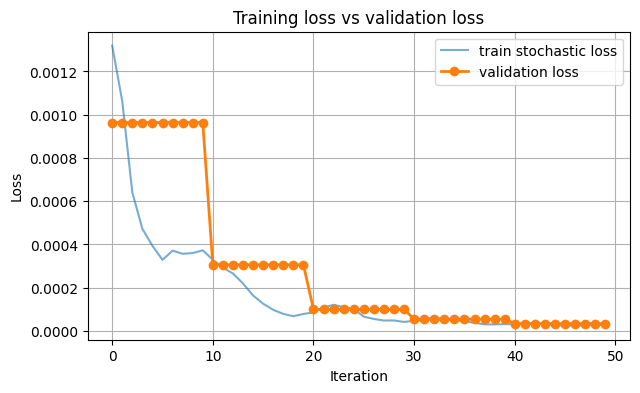

In [26]:
# ============================================================
# Plot training loss and validation loss
# Run this AFTER the FWI loop finishes
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    losshistory,
    label="train stochastic loss",
    alpha=0.6
)

plt.plot(
    validation_losshistory,
    label="validation loss",
    marker="o",
    linewidth=2
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss vs validation loss")
plt.legend()
plt.grid(True)
plt.show()

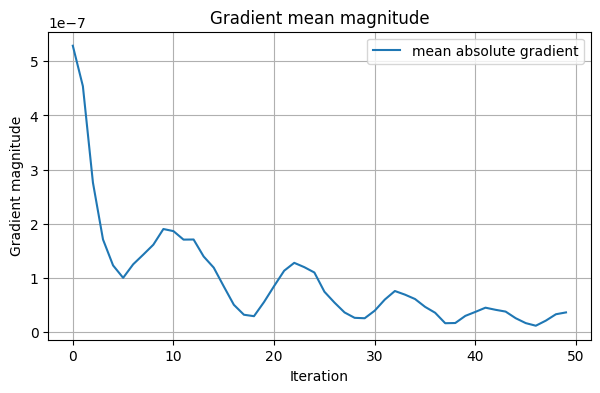

In [27]:
# ============================================================
# Plot gradient diagnostics
# Run this AFTER the FWI loop finishes
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    grad_mean_history,
    label="mean absolute gradient"
)

plt.xlabel("Iteration")
plt.ylabel("Gradient magnitude")
plt.title("Gradient mean magnitude")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

/var/folders/s7/3v2vl8f51x7b9mhx69n0gt480000gn/T/ipykernel_84767/2826385703.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


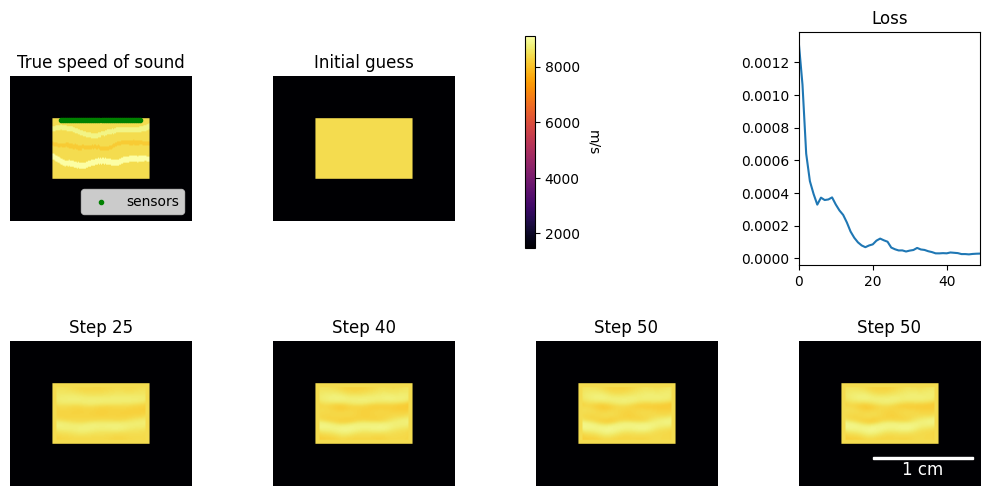

In [29]:
sos_original = get_sound_speed(params).on_grid
true_sos = sound_speed.on_grid
vmin = np.amin(true_sos)
vmax = np.amax(true_sos)

fig, axes = plt.subplots(2, 4, figsize=(10, 5.5))

k = 0
#recs = [24, 39, 69, 99]
recs = [24, 39, 49, 49]
for row in range(2):
    for col in range(4):
        if k == 0:
            axes[row, col].imshow(true_sos, cmap="inferno", vmin=vmin, vmax=vmax)
            axes[row, col].scatter(
                sensors_positions[1],
                sensors_positions[0],
                c="g",
                marker=".",
                label="sensors",
            )
            axes[row, col].legend(loc="lower right")
            axes[row, col].set_title("True speed of sound")
            axes[row, col].set_axis_off()
        elif k == 1:
            im_original = axes[row, col].imshow(sos_original, cmap="inferno", vmin=vmin, vmax=vmax)
            axes[row, col].set_axis_off()
            axes[row, col].set_title("Initial guess")
            
            cbar_ax = fig.add_axes([0.53, 0.54, 0.01, 0.385])
            cbar = plt.colorbar(im_original, cax=cbar_ax)
            cbar.ax.get_yaxis().labelpad = 15
            cbar.ax.set_ylabel('m/s', rotation=270)
        elif k == 2:
            axes[row, col].set_axis_off()
        elif k == 3:
            axes[row, col].plot(losshistory)
            axes[row, col].set_title("Loss")
            #axes[row, col].set_xticks([], [])
            axes[row, col].margins(x=0)
        else:
            axes[row, col].imshow(reconstructions[recs[k - 4]], cmap="inferno", vmin=vmin, vmax=vmax)
            axes[row, col].set_axis_off()
            axes[row, col].set_title("Step {}".format(recs[k - 4] + 1))
        k += 1

# Scale bar
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(
    axes[-1, -1].transData,
    100, '1 cm', 'lower right', 
    pad=0.3,
    color='white',
    frameon=False,
    size_vertical=2,
    fontproperties=fontprops)
axes[-1, -1].add_artist(scalebar)
        
fig.tight_layout()

plt.savefig('fwi.pdf')

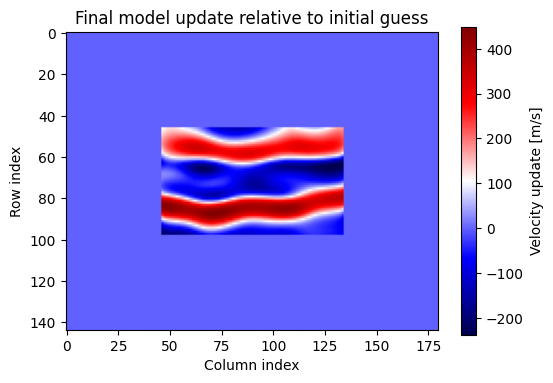

In [30]:
# ============================================================
# Plot model update relative to initial guess
# ============================================================

initial_sos = get_sound_speed(params).on_grid
final_sos = get_sound_speed(get_params(opt_state)).on_grid

model_update = final_sos - initial_sos

plt.figure(figsize=(6, 4))
plt.imshow(model_update, cmap="seismic")
plt.colorbar(label="Velocity update [m/s]")
plt.title("Final model update relative to initial guess")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()

In [31]:
initial_sos = get_sound_speed(params).on_grid
final_sos = get_sound_speed(get_params(opt_state)).on_grid

print("Min update:", float(jnp.min(final_sos - initial_sos)))
print("Max update:", float(jnp.max(final_sos - initial_sos)))
print("Mean abs update:", float(jnp.mean(jnp.abs(final_sos - initial_sos))))

Min update: -238.02734375
Max update: 448.810546875
Mean abs update: 29.13854217529297


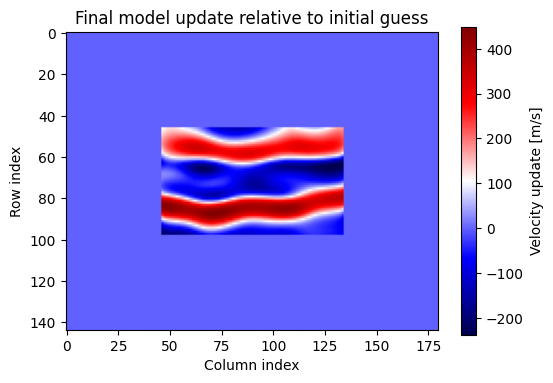

In [32]:
# ============================================================
# Plot final model update relative to initial guess
# ============================================================

plt.figure(figsize=(6, 4))

plt.imshow(
    model_update,
    cmap="seismic"
)

plt.colorbar(label="Velocity update [m/s]")
plt.title("Final model update relative to initial guess")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()

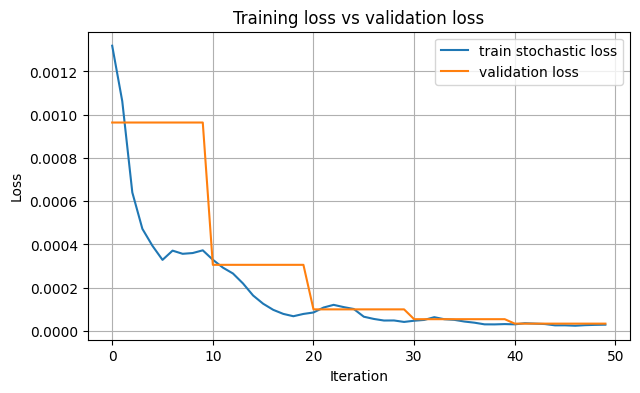

In [33]:

# ============================================================
# Plot training loss and validation loss separately
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    losshistory,
    label="train stochastic loss"
)

plt.plot(
    validation_losshistory,
    label="validation loss"
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss vs validation loss")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
initial_sos = get_sound_speed(params).on_grid[..., 0]
final_sos = get_sound_speed(get_params(opt_state)).on_grid[..., 0]

model_update = final_sos - initial_sos

print("Sources per update:", sources_per_update)
print("Learning rate:", learning_rate)
print("Num steps:", num_steps)
print("Initial validation loss:", validation_losshistory[0])
print("Final validation loss:", validation_losshistory[-1])
print("Min update:", float(jnp.min(model_update)))
print("Max update:", float(jnp.max(model_update)))
print("Mean abs update:", float(jnp.mean(jnp.abs(model_update))))

Sources per update: 4
Learning rate: 0.03
Num steps: 50
Initial validation loss: 0.0009637728799134493
Final validation loss: 3.414263483136892e-05
Min update: -238.02734375
Max update: 448.810546875
Mean abs update: 29.13854217529297


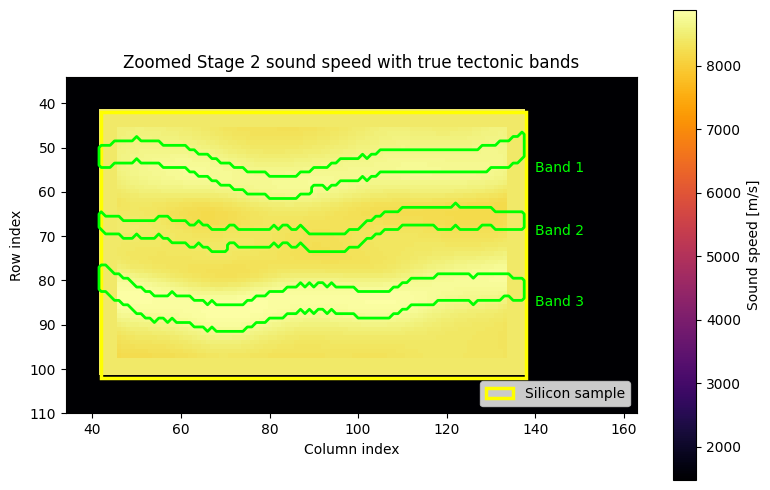

In [35]:
# ============================================================
# Zoomed Stage 2 sound-speed plot around silicon sample
# ============================================================
import matplotlib.patches as patches
plt.figure(figsize=(8, 5))
ax = plt.gca()

margin = 8

im = ax.imshow(
    final_sos,
    cmap="inferno"
)

plt.colorbar(im, label="Sound speed [m/s]")

# Silicon sample boundary
sample_rect = patches.Rectangle(
    (sample_left, sample_top),
    sample_right - sample_left,
    sample_bottom - sample_top,
    fill=False,
    edgecolor="yellow",
    linewidth=2.5,
    label="Silicon sample"
)
ax.add_patch(sample_rect)

# True irregular tectonic bands
if "true_band_masks_from_geometry" in globals():

    for band_number, band_mask in true_band_masks_from_geometry.items():

        # Draw the real irregular/wavy boundary
        ax.contour(
            band_mask.astype(float),
            levels=[0.5],
            colors="lime",
            linewidths=2
        )

        # Put label near the mean vertical position of the irregular band
        geom = tectonic_band_geometry_irregular[band_number - 1]

        mean_y = 0.5 * (
            geom["mean_top_row"]
            + geom["mean_bottom_row"]
        )

        ax.text(
            sample_right + 2,
            mean_y,
            f"Band {band_number}",
            color="lime",
            fontsize=10,
            va="center"
        )

else:

    # Fallback for old rectangular benchmark cases
    for band_number, (z0_frac, z1_frac, contrast) in enumerate(layer_specs, start=1):

        z0 = sample_top + int(z0_frac * sample_N[0])
        z1 = sample_top + int(z1_frac * sample_N[0])

        band_rect = patches.Rectangle(
            (sample_left, z0),
            sample_right - sample_left,
            z1 - z0,
            fill=False,
            edgecolor="lime",
            linewidth=2,
            label="True tectonic bands" if band_number == 1 else None
        )

        ax.add_patch(band_rect)

        ax.text(
            sample_right + 2,
            0.5 * (z0 + z1),
            f"Band {band_number}",
            color="lime",
            fontsize=10,
            va="center"
        )
ax.set_xlim(sample_left - margin, sample_right + 25)
ax.set_ylim(sample_bottom + margin, sample_top - margin)

ax.set_title("Zoomed Stage 2 sound speed with true tectonic bands")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

# End Stage 1 at 20Mhz

# Start of Stage 2 at 85Mhz

In [36]:
# ============================================================
# MULTISCALE FWI STAGE 2
# Use the final 20 MHz reconstruction as initial model
# Then continue inversion at higher frequency
# ============================================================

# Save final low-frequency result
params_stage1 = get_params(opt_state)

stage1_final_sos = get_sound_speed(params_stage1).on_grid[..., 0]

print("Saved stage 1 parameters.")
print("Stage 1 final min speed:", float(jnp.min(stage1_final_sos)))
print("Stage 1 final max speed:", float(jnp.max(stage1_final_sos)))

Saved stage 1 parameters.
Stage 1 final min speed: 1480.0
Stage 1 final max speed: 8881.810546875


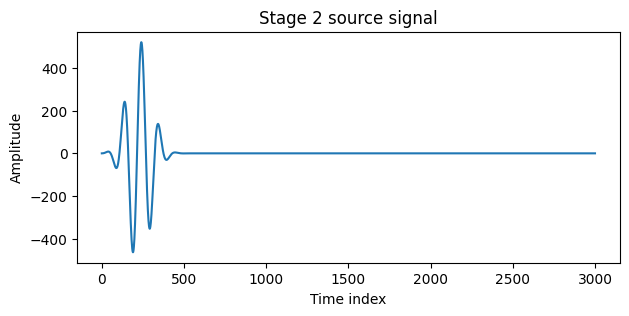

Stage 2 scale factor: 85
Stage 2 source frequency: 85000000.0


In [37]:
# ============================================================
# Define high-frequency source for stage 2
# ============================================================

scale_factor_stage2 = 85

source_freq = 1e6 * scale_factor_stage2

s1 = source_mag * jnp.sin(
    2 * jnp.pi * source_freq * t
)

# Keep same pulse center
center_index = 200
center_time = center_index * time_axis.dt

# You can keep same sigma first
sigma_time = 12e-9

signal = gaussian_window(
    apply_ramp(s1, time_axis.dt, source_freq),
    t,
    center_time,
    sigma_time
)

src_signal = jnp.stack([signal])

plt.figure(figsize=(7, 3))
plt.plot(signal)
plt.title("Stage 2 source signal")
plt.xlabel("Time index")
plt.ylabel("Amplitude")
plt.show()

print("Stage 2 scale factor:", scale_factor_stage2)
print("Stage 2 source frequency:", source_freq)

In [38]:
# ============================================================
# Redefine forward simulation for stage 2
# This uses the new high-frequency source signal
# ============================================================

@jit
def single_source_simulation(sound_speed, source_num):
    x = lax.dynamic_slice(source_positions[0], (source_num,), (1,))
    y = lax.dynamic_slice(source_positions[1], (source_num,), (1,))

    sources = Sources(
        (x, y),
        src_signal,
        dt=time_axis.dt,
        domain=domain
    )

    medium_local = Medium(
        domain=domain,
        sound_speed=sound_speed,
        pml_size=8
    )

    rf_signals = simulate_wave_propagation(
        medium_local,
        time_axis,
        sources=sources,
        sensors=sensors,
    )

    return rf_signals[..., 0]

Stage 2 clean data shape: (40, 3000, 40)


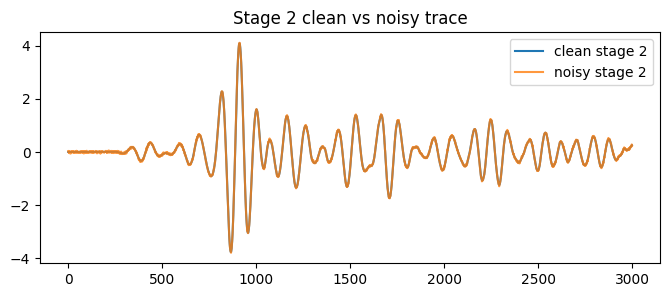

In [39]:
# ============================================================
# Generate high-frequency observed data for stage 2
# Synthetic case: true data comes from medium.sound_speed
# ============================================================

batch_simulations = vmap(single_source_simulation, in_axes=(None, 0))

p_data_clean_stage2 = batch_simulations(
    medium.sound_speed,
    jnp.arange(num_sources)
)

print("Stage 2 clean data shape:", p_data_clean_stage2.shape)

# Add same relative noise level as before
noise_level = 0.005

p_clean = np.array(p_data_clean_stage2)

trace_scale = np.max(
    np.abs(p_clean),
    axis=1,
    keepdims=True
)

trace_scale[trace_scale == 0] = 1.0

noise = (
    np.random.normal(size=p_clean.shape)
    * noise_level
    * trace_scale
)

p_data = jnp.array(p_clean + noise)

plt.figure(figsize=(8, 3))
plt.plot(p_clean[20, :, 0], label="clean stage 2")
plt.plot(p_data[20, :, 0], label="noisy stage 2", alpha=0.8)
plt.title("Stage 2 clean vs noisy trace")
plt.legend()
plt.show()

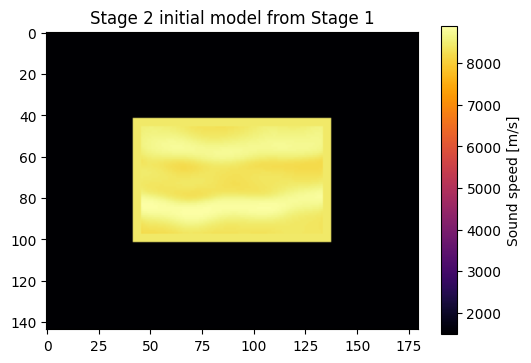

In [40]:
# ============================================================
# Stage 2 initial model = final Stage 1 model
# ============================================================

params = params_stage1

initial_stage2_sos = get_sound_speed(params).on_grid[..., 0]

plt.figure(figsize=(6, 4))
plt.imshow(initial_stage2_sos, cmap="inferno")
plt.colorbar(label="Sound speed [m/s]")
plt.title("Stage 2 initial model from Stage 1")
plt.show()

In [41]:
# ============================================================
# Rebuild loss_with_grad for stage 2
# ============================================================

loss_with_grad = value_and_grad(loss_func, argnums=0)

print("Stage 2 using loss function:", loss_name)
print("Stage 2 regularization weight:", regularization_weight)
print("Stage 2 negative update penalty:", use_negative_update_penalty)

Stage 2 using loss function: amplitude_envelope
Stage 2 regularization weight: 1e-05
Stage 2 negative update penalty: False


In [42]:
# ============================================================
# Stage 2 optimization
# ============================================================

losshistory_stage2 = []
validation_losshistory_stage2 = []
reconstructions_stage2 = []

grad_mean_history_stage2 = []
grad_min_history_stage2 = []
grad_max_history_stage2 = []

num_steps_stage2 = 50
learning_rate_stage2 = 0.01     # safer for high frequency
sources_per_update = 4

init_fun, update_fun, get_params = optimizers.adam(
    learning_rate_stage2,
    0.9,
    0.9
)

opt_state = init_fun(params)


@jit
def update_stage2(opt_state, key, k):
    v = get_params(opt_state)

    src_nums = random.choice(
        key,
        num_sources,
        shape=(sources_per_update,),
        replace=False
    )

    loss_sum = 0.0
    grad_grid_sum = jnp.zeros_like(v.on_grid)

    for i in range(sources_per_update):
        src_num = src_nums[i]

        loss_i, grad_i = loss_with_grad(v, src_num)

        loss_sum = loss_sum + loss_i
        grad_grid_sum = grad_grid_sum + grad_i.on_grid

    lossval = loss_sum / sources_per_update
    gradient_grid = grad_grid_sum / sources_per_update

    gradient = FourierSeries(
        gradient_grid,
        domain
    )

    grad_min = jnp.min(gradient_grid)
    grad_max = jnp.max(gradient_grid)
    grad_mean = jnp.mean(jnp.abs(gradient_grid))

    # Keep gradient smoothing OFF first
    # gradient = smooth_fun(gradient)

    return (
        lossval,
        update_fun(k, gradient, opt_state),
        grad_min,
        grad_max,
        grad_mean
    )


pbar = tqdm(range(num_steps_stage2))

_, key = random.split(random_seed)

for k in pbar:
    _, key = random.split(key)

    lossval, opt_state, grad_min, grad_max, grad_mean = update_stage2(
        opt_state,
        key,
        k
    )

    new_params = get_params(opt_state)

    reconstructions_stage2.append(
        get_sound_speed(new_params).on_grid
    )

    losshistory_stage2.append(float(lossval))

    grad_min_history_stage2.append(float(grad_min))
    grad_max_history_stage2.append(float(grad_max))
    grad_mean_history_stage2.append(float(grad_mean))

    if k % 5 == 0:
        val_loss = validation_loss(new_params)
        validation_losshistory_stage2.append(float(val_loss))
    else:
        validation_losshistory_stage2.append(
            validation_losshistory_stage2[-1]
        )

    pbar.set_description(
        "Stage 2 loss: {:.6f}, Val loss: {:.6f}, Grad mean: {:.3e}".format(
            float(lossval),
            validation_losshistory_stage2[-1],
            float(grad_mean)
        )
    )

Stage 2 loss: 0.000600, Val loss: 0.000624, Grad mean: 1.362e-07: 100%|███| 50/50 [24:08<00:00, 28.97s/it]


In [61]:
# ============================================================
# BENCHMARK CONFIGURATION LABEL
# Change this manually for each experiment
# ============================================================

benchmark_num_bands = 3   # change to 6, 8, or 10
benchmark_geometry_label = "realistic_tectonic"

stage1_frequency_MHz = 20
stage2_frequency_MHz = 85


output_dir = (
    f"fwi_{stage1_frequency_MHz}MHz_to_{stage2_frequency_MHz}MHz_"
    f"{benchmark_num_bands}bands_{benchmark_geometry_label}_results"
)

print("Benchmark output folder:", output_dir)

Benchmark output folder: fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results


In [62]:
# ============================================================
# FIGURE SAVE SETUP
# Save all figures inside the benchmark output folder
# ============================================================

import os
import matplotlib.pyplot as plt

# Create main output folder
os.makedirs(output_dir, exist_ok=True)

# Create figures folder inside output_dir
fig_dir = os.path.join(output_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

print("Figures will be saved in:")
print(fig_dir)


def save_current_figure(figure_name, dpi=300):
    """
    Save the current matplotlib figure inside the benchmark figures folder.

    Example:
        save_current_figure("stage2_reconstructed_sound_speed")
    """

    filename = (
        f"{figure_name}_"
        f"{stage1_frequency_MHz}MHz_to_{stage2_frequency_MHz}MHz_"
        f"{benchmark_num_bands}bands.png"
    )

    save_path = os.path.join(fig_dir, filename)

    plt.savefig(
        save_path,
        dpi=dpi,
        bbox_inches="tight"
    )

    print("Saved figure:")
    print(save_path)

    return save_path

Figures will be saved in:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/figures


Saved figure:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/figures/Stage 2: Training loss vs validation loss_20MHz_to_85MHz_3bands.png


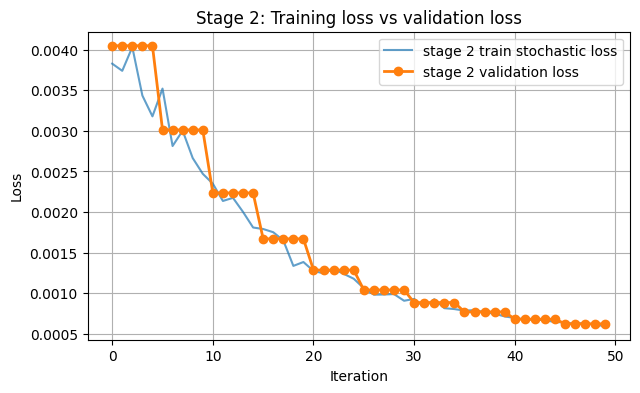

Saved figure:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/figures/Stage 2 gradient mean magnitude_20MHz_to_85MHz_3bands.png


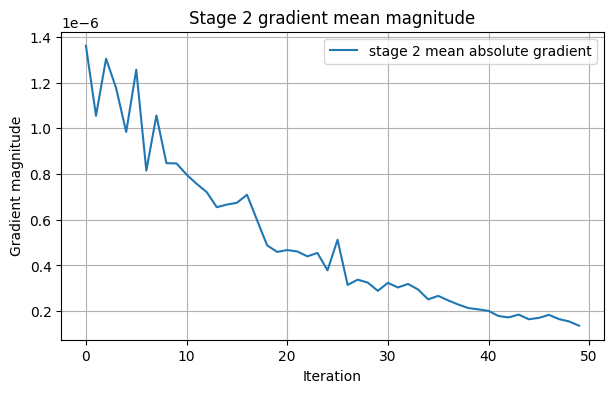

In [63]:
# ============================================================
# Stage 2 diagnostics
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    losshistory_stage2,
    label="stage 2 train stochastic loss",
    alpha=0.7
)

plt.plot(
    validation_losshistory_stage2,
    label="stage 2 validation loss",
    marker="o",
    linewidth=2
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Stage 2: Training loss vs validation loss")
plt.legend()
plt.grid(True)
save_current_figure("Stage 2: Training loss vs validation loss")
plt.show()


plt.figure(figsize=(7, 4))

plt.plot(
    grad_mean_history_stage2,
    label="stage 2 mean absolute gradient"
)

plt.xlabel("Iteration")
plt.ylabel("Gradient magnitude")
plt.title("Stage 2 gradient mean magnitude")
plt.legend()
plt.grid(True)
save_current_figure("Stage 2 gradient mean magnitude")
plt.show()

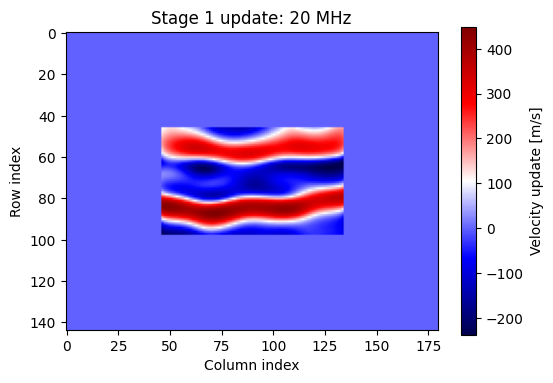

Saved figure:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/figures/Stage 2 total update: 20 MHz to 85 MHz_20MHz_to_85MHz_3bands.png


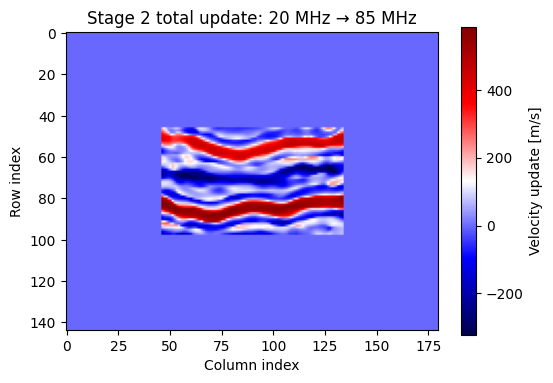

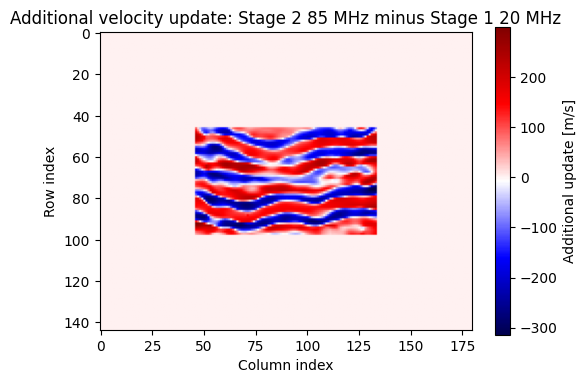

Stage 2 summary
Sources per update: 4
Stage 2 learning rate: 0.01
Stage 2 steps: 50
Stage 2 initial validation loss: 0.004048006609082222
Stage 2 final validation loss: 0.0006240943330340087
Stage 2 min total update: -322.53662109375
Stage 2 max total update: 585.7734375
Stage 2 mean abs total update: 29.393569946289062
Stage 2 extra min update: -314.4296875
Stage 2 extra max update: 299.8134765625
Stage 2 extra mean abs update: 22.952707290649414


In [64]:
# ============================================================
# Compare Stage 1 and Stage 2 velocity updates
# ============================================================

initial_sos = get_sound_speed(medium.sound_speed * 0.0).on_grid[..., 0]

stage1_sos = get_sound_speed(params_stage1).on_grid[..., 0]
stage2_sos = get_sound_speed(get_params(opt_state)).on_grid[..., 0]

stage1_update = stage1_sos - initial_sos
stage2_update = stage2_sos - initial_sos
stage2_extra_update = stage2_sos - stage1_sos

plt.figure(figsize=(6, 4))
plt.imshow(stage1_update, cmap="seismic")
plt.colorbar(label="Velocity update [m/s]")
plt.title("Stage 1 update: 20 MHz")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(stage2_update, cmap="seismic")
plt.colorbar(label="Velocity update [m/s]")
plt.title("Stage 2 total update: 20 MHz → 85 MHz")
plt.xlabel("Column index")
plt.ylabel("Row index")
save_current_figure("Stage 2 total update: 20 MHz to 85 MHz")

plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(stage2_extra_update, cmap="seismic")
plt.colorbar(label="Additional update [m/s]")
plt.title("Additional velocity update: Stage 2 85 MHz minus Stage 1 20 MHz")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()

print("Stage 2 summary")
print("Sources per update:", sources_per_update)
print("Stage 2 learning rate:", learning_rate_stage2)
print("Stage 2 steps:", num_steps_stage2)
print("Stage 2 initial validation loss:", validation_losshistory_stage2[0])
print("Stage 2 final validation loss:", validation_losshistory_stage2[-1])
print("Stage 2 min total update:", float(jnp.min(stage2_update)))
print("Stage 2 max total update:", float(jnp.max(stage2_update)))
print("Stage 2 mean abs total update:", float(jnp.mean(jnp.abs(stage2_update))))
print("Stage 2 extra min update:", float(jnp.min(stage2_extra_update)))
print("Stage 2 extra max update:", float(jnp.max(stage2_extra_update)))
print("Stage 2 extra mean abs update:", float(jnp.mean(jnp.abs(stage2_extra_update))))

Saved figure:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/figures/Stage 2 reconstructed sound speed without boundaries_20MHz_to_85MHz_3bands.png


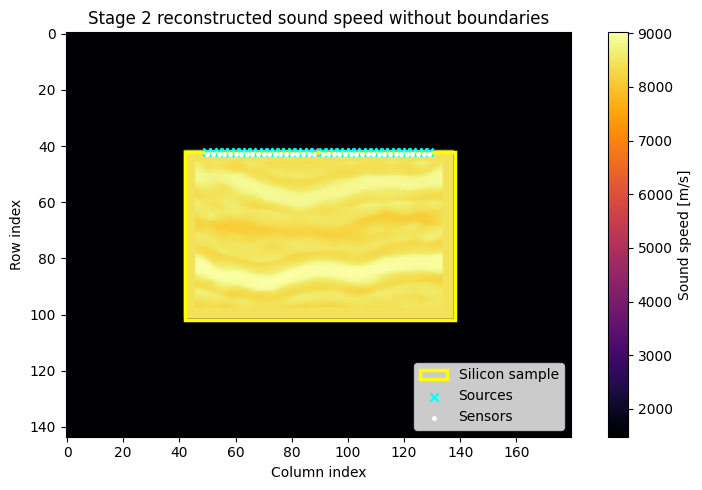

In [65]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ============================================================
# Plot Stage 2 reconstructed sound speed with boundaries
# ============================================================

stage2_sos_np = np.array(stage2_sos)

plt.figure(figsize=(8, 5))
ax = plt.gca()

im = ax.imshow(
    stage2_sos_np,
    cmap="inferno"
)

plt.colorbar(im, label="Sound speed [m/s]")

# ------------------------------------------------------------
# Silicon sample boundary
# ------------------------------------------------------------

sample_rect = patches.Rectangle(
    (sample_left, sample_top),
    sample_right - sample_left,
    sample_bottom - sample_top,
    fill=False,
    edgecolor="yellow",
    linewidth=2.5,
    label="Silicon sample"
)

ax.add_patch(sample_rect)

# ------------------------------------------------------------
# True tectonic band boundaries
# ------------------------------------------------------------

# ------------------------------------------------------------
# Optional: show sources and sensors
# ------------------------------------------------------------

ax.scatter(
    source_positions[1],
    source_positions[0],
    c="cyan",
    marker="x",
    s=35,
    label="Sources"
)

ax.scatter(
    sensors_positions[1],
    sensors_positions[0],
    c="white",
    marker=".",
    s=25,
    label="Sensors"
)

# ------------------------------------------------------------
# Plot labels
# ------------------------------------------------------------

ax.set_title("Stage 2 reconstructed sound speed without boundaries")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")

ax.legend(loc="lower right")

plt.tight_layout()
save_current_figure("Stage 2 reconstructed sound speed without boundaries")
plt.show()

Saved figure:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/figures/Stage 2 reconstructed sound speed with true band boundaries_20MHz_to_85MHz_3bands.png


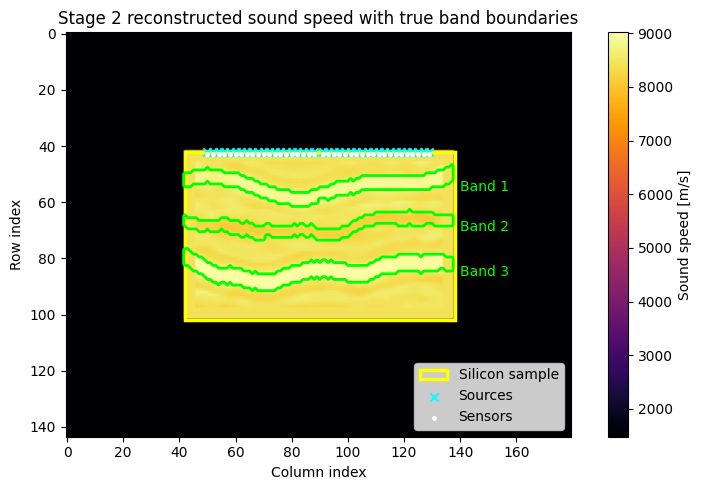

In [66]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ============================================================
# Plot Stage 2 reconstructed sound speed with boundaries
# ============================================================

stage2_sos_np = np.array(stage2_sos)

plt.figure(figsize=(8, 5))
ax = plt.gca()

im = ax.imshow(
    stage2_sos_np,
    cmap="inferno"
)

plt.colorbar(im, label="Sound speed [m/s]")

# ------------------------------------------------------------
# Silicon sample boundary
# ------------------------------------------------------------

sample_rect = patches.Rectangle(
    (sample_left, sample_top),
    sample_right - sample_left,
    sample_bottom - sample_top,
    fill=False,
    edgecolor="yellow",
    linewidth=2.5,
    label="Silicon sample"
)

ax.add_patch(sample_rect)

# ------------------------------------------------------------
# True tectonic band boundaries
# ------------------------------------------------------------

# True tectonic bands
if "true_band_masks_from_geometry" in globals():

    for band_number, band_mask in true_band_masks_from_geometry.items():

        ax.contour(
            band_mask.astype(float),
            levels=[0.5],
            colors="lime",
            linewidths=2
        )

        geom = tectonic_band_geometry_irregular[band_number - 1]

        mean_y = 0.5 * (
            geom["mean_top_row"]
            + geom["mean_bottom_row"]
        )

        ax.text(
            sample_right + 2,
            mean_y,
            f"Band {band_number}",
            color="lime",
            fontsize=10,
            va="center"
        )

else:

    for band_number, (z0_frac, z1_frac, contrast) in enumerate(layer_specs, start=1):

        z0 = sample_top + int(z0_frac * sample_N[0])
        z1 = sample_top + int(z1_frac * sample_N[0])

        band_rect = patches.Rectangle(
            (sample_left, z0),
            sample_right - sample_left,
            z1 - z0,
            fill=False,
            edgecolor="lime",
            linewidth=2,
            label="True tectonic bands" if band_number == 1 else None
        )

        ax.add_patch(band_rect)

        ax.text(
            sample_right + 2,
            0.5 * (z0 + z1),
            f"Band {band_number}",
            color="lime",
            fontsize=10,
            va="center"
        )

# ------------------------------------------------------------
# Optional: show sources and sensors
# ------------------------------------------------------------

ax.scatter(
    source_positions[1],
    source_positions[0],
    c="cyan",
    marker="x",
    s=35,
    label="Sources"
)

ax.scatter(
    sensors_positions[1],
    sensors_positions[0],
    c="white",
    marker=".",
    s=25,
    label="Sensors"
)

# ------------------------------------------------------------
# Plot labels
# ------------------------------------------------------------

ax.set_title("Stage 2 reconstructed sound speed with true band boundaries")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")

ax.legend(loc="lower right")

plt.tight_layout()
save_current_figure("Stage 2 reconstructed sound speed with true band boundaries")

plt.show()

Saved figure:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/figures/Zoomed Stage 2 sound speed with true tectonic bands_20MHz_to_85MHz_3bands.png


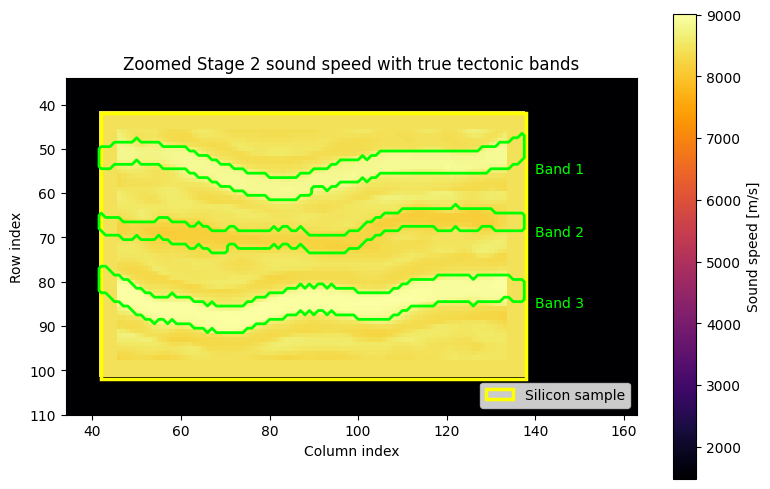

In [67]:
# ============================================================
# Zoomed Stage 2 sound-speed plot around silicon sample
# ============================================================

plt.figure(figsize=(8, 5))
ax = plt.gca()

margin = 8

im = ax.imshow(
    stage2_sos_np,
    cmap="inferno"
)

plt.colorbar(im, label="Sound speed [m/s]")

# Silicon sample boundary
sample_rect = patches.Rectangle(
    (sample_left, sample_top),
    sample_right - sample_left,
    sample_bottom - sample_top,
    fill=False,
    edgecolor="yellow",
    linewidth=2.5,
    label="Silicon sample"
)
ax.add_patch(sample_rect)

# True tectonic bands
if "true_band_masks_from_geometry" in globals():

    for band_number, band_mask in true_band_masks_from_geometry.items():

        ax.contour(
            band_mask.astype(float),
            levels=[0.5],
            colors="lime",
            linewidths=2
        )

        geom = tectonic_band_geometry_irregular[band_number - 1]

        mean_y = 0.5 * (
            geom["mean_top_row"]
            + geom["mean_bottom_row"]
        )

        ax.text(
            sample_right + 2,
            mean_y,
            f"Band {band_number}",
            color="lime",
            fontsize=10,
            va="center"
        )

else:

    for band_number, (z0_frac, z1_frac, contrast) in enumerate(layer_specs, start=1):

        z0 = sample_top + int(z0_frac * sample_N[0])
        z1 = sample_top + int(z1_frac * sample_N[0])

        band_rect = patches.Rectangle(
            (sample_left, z0),
            sample_right - sample_left,
            z1 - z0,
            fill=False,
            edgecolor="lime",
            linewidth=2,
            label="True tectonic bands" if band_number == 1 else None
        )

        ax.add_patch(band_rect)

        ax.text(
            sample_right + 2,
            0.5 * (z0 + z1),
            f"Band {band_number}",
            color="lime",
            fontsize=10,
            va="center"
        )

ax.set_xlim(sample_left - margin, sample_right + 25)
ax.set_ylim(sample_bottom + margin, sample_top - margin)

ax.set_title("Zoomed Stage 2 sound speed with true tectonic bands")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")
ax.legend(loc="lower right")

plt.tight_layout()
save_current_figure("Zoomed Stage 2 sound speed with true tectonic bands")
plt.show()

Saved figure:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/figures/Stage 2 error inside inversion mask: reconstruction minus ground truth_20MHz_to_85MHz_3bands.png


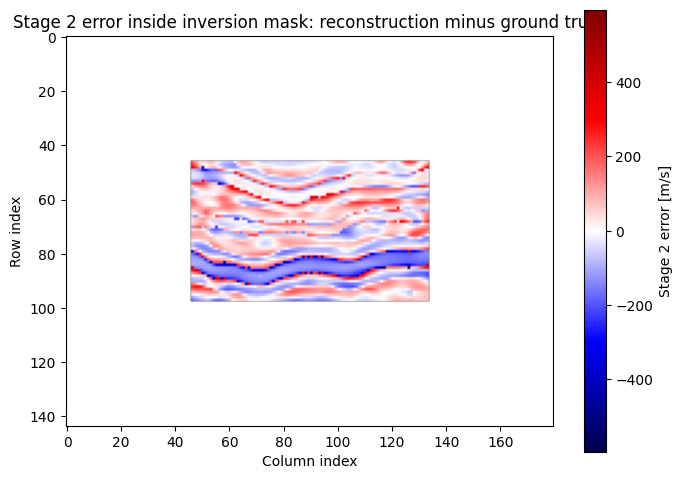

Stage 2 error summary inside inversion mask
Min error [m/s]: -594.7842
Max error [m/s]: 485.12305
Mean signed error [m/s]: 0.55317146
Mean absolute error [m/s]: 87.98315


In [68]:
# ============================================================
# Stage 2 error relative to ground truth, only inside inversion mask
# ============================================================

true_sos = medium.sound_speed.on_grid[..., 0]

stage2_error = stage2_sos - true_sos

# Convert to numpy for masking
stage2_error_np = np.array(stage2_error)
inside_inversion_mask_np = np.array(mask_grid).astype(bool)

# Hide everything outside the inversion mask
stage2_error_masked = np.where(
    inside_inversion_mask_np,
    stage2_error_np,
    np.nan
)

absmax_error = np.nanmax(np.abs(stage2_error_masked))

plt.figure(figsize=(7, 5))

plt.imshow(
    stage2_error_masked,
    cmap="seismic",
    vmin=-absmax_error,
    vmax=absmax_error
)

plt.colorbar(label="Stage 2 error [m/s]")
plt.title("Stage 2 error inside inversion mask: reconstruction minus ground truth")
plt.xlabel("Column index")
plt.ylabel("Row index")

plt.tight_layout()
save_current_figure("Stage 2 error inside inversion mask: reconstruction minus ground truth")
plt.show()

print("Stage 2 error summary inside inversion mask")
print("Min error [m/s]:", np.nanmin(stage2_error_masked))
print("Max error [m/s]:", np.nanmax(stage2_error_masked))
print("Mean signed error [m/s]:", np.nanmean(stage2_error_masked))
print("Mean absolute error [m/s]:", np.nanmean(np.abs(stage2_error_masked)))


In [69]:
# ============================================================
# FINAL SCIENTIFIC CSV ANALYSIS FOR STAGE 1 AND STAGE 2 FWI
# ============================================================
#
# Required variables from previous notebook cells:
#   medium, get_sound_speed, params_stage1, opt_state, get_params
#   stage1_sos, stage2_sos
#   sample_mask, mask_grid
#   layer_specs
#   sample_top, sample_bottom, sample_left, sample_right
#   sample_N, N, dx
#   si_speed, water_speed
#
# This block creates:
#   1. Long-format pixel map with x/z positions and band labels
#   2. True tectonic band geometry table
#   3. Global reconstruction metrics
#   4. Band-by-band scientific metrics
#   5. Stage 1 vs Stage 2 band improvement table
#   6. Metric dictionary
#   7. Plain-language conclusions
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# Convert maps to NumPy arrays
# ------------------------------------------------------------

true_sos_np = np.array(medium.sound_speed.on_grid[..., 0])

initial_sos_np = np.array(
    get_sound_speed(medium.sound_speed * 0.0).on_grid[..., 0]
)

stage1_sos_np = np.array(stage1_sos)
stage2_sos_np = np.array(stage2_sos)

stage1_update_np = stage1_sos_np - initial_sos_np
stage2_update_np = stage2_sos_np - initial_sos_np
stage2_extra_update_np = stage2_sos_np - stage1_sos_np

sample_mask_np = np.array(sample_mask).astype(int)
mask_grid_np = np.array(mask_grid).astype(int)

inside_silicon = sample_mask_np == 1
inside_inversion_mask = mask_grid_np == 1

# ------------------------------------------------------------
# Basic geometry check
# ------------------------------------------------------------

print("Full domain shape:", true_sos_np.shape)
print("Silicon sample rows:", sample_top, "to", sample_bottom - 1)
print("Silicon sample columns:", sample_left, "to", sample_right - 1)
print("Grid spacing z [um]:", dx[0] * 1e6)
print("Grid spacing x [um]:", dx[1] * 1e6)

# ============================================================
# 1. LONG-FORMAT PIXEL MAP
# ============================================================
# One row = one grid pixel.
# This is the most useful scientific map file.
# It connects every value to physical x/z position and band label.
# ============================================================

row_index_z, column_index_x = np.indices(true_sos_np.shape)

# Global coordinates measured from top-left corner of full water+silicon domain
z_depth_global_um = row_index_z * dx[0] * 1e6
x_position_global_um = column_index_x * dx[1] * 1e6

# Coordinates relative to top-left corner of silicon sample
z_depth_inside_silicon_um = (row_index_z - sample_top) * dx[0] * 1e6
x_position_inside_silicon_um = (column_index_x - sample_left) * dx[1] * 1e6

z_depth_inside_silicon_um = z_depth_inside_silicon_um.astype(float)
x_position_inside_silicon_um = x_position_inside_silicon_um.astype(float)

# Outside silicon, silicon-relative coordinates are not meaningful
z_depth_inside_silicon_um[~inside_silicon] = np.nan
x_position_inside_silicon_um[~inside_silicon] = np.nan

# Region labels
region_label = np.full(true_sos_np.shape, "water_outside_silicon", dtype=object)
region_label[inside_silicon] = "silicon_background"

tectonic_band_number_map = np.full(true_sos_np.shape, np.nan)
tectonic_band_type_map = np.full(true_sos_np.shape, "none", dtype=object)
true_band_contrast_percent_map = np.full(true_sos_np.shape, np.nan)

true_band_masks = {}

for band_number, (z0_frac, z1_frac, contrast) in enumerate(layer_specs, start=1):

    # --------------------------------------------------------
    # Base rectangular geometry
    # Used only as fallback and for approximate geometry labels
    # --------------------------------------------------------

    band_top_row = sample_top + int(z0_frac * sample_N[0])
    band_bottom_row = sample_top + int(z1_frac * sample_N[0])

    # --------------------------------------------------------
    # Correct true band mask
    # For realistic tectonic geometry, use the stored irregular mask.
    # For old rectangular benchmarks, rebuild the rectangular mask.
    # --------------------------------------------------------

    if "true_band_masks_from_geometry" in globals():
        band_mask = true_band_masks_from_geometry[band_number].copy()
    else:
        band_mask = np.zeros(true_sos_np.shape, dtype=bool)

        band_mask[
            band_top_row:band_bottom_row,
            sample_left:sample_right
        ] = True

    # Keep only pixels inside silicon
    band_mask = band_mask & inside_silicon

    # --------------------------------------------------------
    # Band type label
    # --------------------------------------------------------

    if contrast > 0:
        band_type = "fast"
    elif contrast < 0:
        band_type = "slow"
    else:
        band_type = "neutral"

    # --------------------------------------------------------
    # Fill long-format label maps
    # --------------------------------------------------------

    region_label[band_mask] = f"tectonic_band_{band_number}_{band_type}"
    tectonic_band_number_map[band_mask] = band_number
    tectonic_band_type_map[band_mask] = band_type
    true_band_contrast_percent_map[band_mask] = 100.0 * contrast

    # Save correct mask for later band-by-band metrics
    true_band_masks[band_number] = band_mask

# True contrast relative to silicon
true_velocity_contrast_percent = 100.0 * (true_sos_np - si_speed) / si_speed
true_velocity_contrast_percent[~inside_silicon] = np.nan

# Error maps
stage1_error_np = stage1_sos_np - true_sos_np
stage2_error_np = stage2_sos_np - true_sos_np

stage1_abs_error_np = np.abs(stage1_error_np)
stage2_abs_error_np = np.abs(stage2_error_np)

# Positive means Stage 2 improved at this pixel.
# Negative means Stage 2 became worse at this pixel.
stage2_pixel_error_improvement_np = stage1_abs_error_np - stage2_abs_error_np

map_long_df = pd.DataFrame({
    "row_index_z_depth_direction": row_index_z.ravel(),
    "column_index_x_horizontal_direction": column_index_x.ravel(),

    "z_depth_global_micrometers": z_depth_global_um.ravel(),
    "x_position_global_micrometers": x_position_global_um.ravel(),

    "z_depth_inside_silicon_micrometers": z_depth_inside_silicon_um.ravel(),
    "x_position_inside_silicon_micrometers": x_position_inside_silicon_um.ravel(),

    "inside_silicon_sample": np.where(inside_silicon.ravel(), "yes", "no"),
    "inside_inversion_mask": np.where(inside_inversion_mask.ravel(), "yes", "no"),

    "region_label": region_label.ravel(),
    "tectonic_band_number": tectonic_band_number_map.ravel(),
    "tectonic_band_type": tectonic_band_type_map.ravel(),

    "true_sound_speed_m_per_s": true_sos_np.ravel(),
    "true_velocity_contrast_percent_relative_to_silicon": true_velocity_contrast_percent.ravel(),
    "true_band_contrast_percent": true_band_contrast_percent_map.ravel(),

    "initial_sound_speed_m_per_s": initial_sos_np.ravel(),

    "stage1_sound_speed_m_per_s": stage1_sos_np.ravel(),
    "stage2_sound_speed_m_per_s": stage2_sos_np.ravel(),

    "stage1_velocity_update_relative_to_initial_m_per_s": stage1_update_np.ravel(),
    "stage2_velocity_update_relative_to_initial_m_per_s": stage2_update_np.ravel(),
    "stage2_extra_update_relative_to_stage1_m_per_s": stage2_extra_update_np.ravel(),

    "stage1_error_reconstructed_minus_true_m_per_s": stage1_error_np.ravel(),
    "stage2_error_reconstructed_minus_true_m_per_s": stage2_error_np.ravel(),

    "stage1_absolute_error_m_per_s": stage1_abs_error_np.ravel(),
    "stage2_absolute_error_m_per_s": stage2_abs_error_np.ravel(),

    "stage2_pixel_error_improvement_m_per_s": stage2_pixel_error_improvement_np.ravel(),
})

map_long_csv = os.path.join(
    output_dir,
    "MAP_LONG_FORMAT_all_pixels_with_x_z_positions_band_labels_and_errors.csv"
)

map_long_df.to_csv(map_long_csv, index=False)

display(map_long_df.head(20))

print("Saved long-format scientific map CSV:")
print(map_long_csv)

# ============================================================
# 2. TRUE TECTONIC BAND GEOMETRY TABLE
# ============================================================

band_geometry_rows = []

for band_number, (z0_frac, z1_frac, contrast) in enumerate(layer_specs, start=1):

    band_top_row = sample_top + int(z0_frac * sample_N[0])
    band_bottom_row = sample_top + int(z1_frac * sample_N[0])
    band_last_included_row = band_bottom_row - 1

    band_center_row = 0.5 * (band_top_row + band_last_included_row)

    band_top_depth_inside_silicon_um = (band_top_row - sample_top) * dx[0] * 1e6
    band_bottom_depth_inside_silicon_um = (band_bottom_row - sample_top) * dx[0] * 1e6
    band_center_depth_inside_silicon_um = (band_center_row - sample_top) * dx[0] * 1e6

    band_left_x_inside_silicon_um = 0.0
    band_right_x_inside_silicon_um = sample_N[1] * dx[1] * 1e6

    band_thickness_cells = band_bottom_row - band_top_row
    band_thickness_um = band_thickness_cells * dx[0] * 1e6

    true_band_speed = si_speed * (1.0 + contrast)
    true_velocity_update = true_band_speed - si_speed

    if contrast > 0:
        band_type = "fast band"
    elif contrast < 0:
        band_type = "slow band"
    else:
        band_type = "neutral band"

    band_geometry_rows.append({
        "tectonic_band_number": band_number,
        "band_type": band_type,

        "true_velocity_contrast_percent": 100.0 * contrast,
        "silicon_background_speed_m_per_s": si_speed,
        "true_band_speed_m_per_s": true_band_speed,
        "true_velocity_update_relative_to_silicon_m_per_s": true_velocity_update,

        "top_row_index_global": band_top_row,
        "bottom_row_index_global_exclusive": band_bottom_row,
        "last_included_row_index_global": band_last_included_row,
        "center_row_index_global": band_center_row,

        "top_depth_inside_silicon_micrometers": band_top_depth_inside_silicon_um,
        "bottom_depth_inside_silicon_micrometers_exclusive": band_bottom_depth_inside_silicon_um,
        "center_depth_inside_silicon_micrometers": band_center_depth_inside_silicon_um,

        "left_column_index_global": sample_left,
        "right_column_index_global_exclusive": sample_right,
        "left_x_inside_silicon_micrometers": band_left_x_inside_silicon_um,
        "right_x_inside_silicon_micrometers_exclusive": band_right_x_inside_silicon_um,

        "band_thickness_cells": band_thickness_cells,
        "band_thickness_micrometers": band_thickness_um,
    })
    # ------------------------------------------------------------
    # Add irregular geometry information when available
    # ------------------------------------------------------------
    
    if "tectonic_band_geometry_irregular" in globals():
    
        irregular_geom = tectonic_band_geometry_irregular[band_number - 1]
    
        band_geometry_rows[-1]["geometry_type"] = "realistic_irregular_tectonic"
    
        band_geometry_rows[-1]["mean_top_row_irregular"] = irregular_geom["mean_top_row"]
        band_geometry_rows[-1]["mean_bottom_row_irregular"] = irregular_geom["mean_bottom_row"]
    
        band_geometry_rows[-1]["mean_top_depth_inside_silicon_micrometers_irregular"] = (
            irregular_geom["mean_top_row"] - sample_top
        ) * dx[0] * 1e6
    
        band_geometry_rows[-1]["mean_bottom_depth_inside_silicon_micrometers_irregular"] = (
            irregular_geom["mean_bottom_row"] - sample_top
        ) * dx[0] * 1e6
    
        band_geometry_rows[-1]["mean_thickness_cells_irregular"] = irregular_geom["mean_thickness_cells"]
        band_geometry_rows[-1]["min_thickness_cells_irregular"] = irregular_geom["min_thickness_cells"]
        band_geometry_rows[-1]["max_thickness_cells_irregular"] = irregular_geom["max_thickness_cells"]
    
        band_geometry_rows[-1]["mean_thickness_micrometers_irregular"] = (
            irregular_geom["mean_thickness_cells"] * dx[0] * 1e6
        )
    
        band_geometry_rows[-1]["min_thickness_micrometers_irregular"] = (
            irregular_geom["min_thickness_cells"] * dx[0] * 1e6
        )
    
        band_geometry_rows[-1]["max_thickness_micrometers_irregular"] = (
            irregular_geom["max_thickness_cells"] * dx[0] * 1e6
        )
    
    else:
    
        band_geometry_rows[-1]["geometry_type"] = "rectangular_horizontal"



band_geometry_df = pd.DataFrame(band_geometry_rows)

band_geometry_csv = os.path.join(
    output_dir,
    "TABLE_true_tectonic_band_geometry_READABLE.csv"
)

band_geometry_df.to_csv(band_geometry_csv, index=False)

display(band_geometry_df)

print("Saved true tectonic band geometry CSV:")
print(band_geometry_csv)

# ============================================================
# 3. GLOBAL RECONSTRUCTION METRICS
# ============================================================

eval_mask = inside_inversion_mask

true_eval = true_sos_np[eval_mask]
stage1_eval = stage1_sos_np[eval_mask]
stage2_eval = stage2_sos_np[eval_mask]


def compute_global_metrics_for_stage(reconstructed, true, stage_name, stage_description):
    error = reconstructed - true

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    bias = np.mean(error)

    true_range = np.max(true) - np.min(true)

    if true_range > 0:
        nrmse_percent = 100.0 * rmse / true_range
    else:
        nrmse_percent = np.nan

    if np.std(reconstructed) > 0 and np.std(true) > 0:
        correlation = np.corrcoef(reconstructed.ravel(), true.ravel())[0, 1]
    else:
        correlation = np.nan

    return [
        {
            "FWI stage": stage_name,
            "Stage description": stage_description,
            "Metric short name": "MAE",
            "Metric full name": "Mean Absolute Error",
            "Value": mae,
            "Unit": "m/s",
            "Formula used": "mean(abs(reconstructed_speed - true_speed))",
            "Meaning": "Average absolute velocity error inside the inversion mask.",
            "Good result": "Lower is better."
        },
        {
            "FWI stage": stage_name,
            "Stage description": stage_description,
            "Metric short name": "RMSE",
            "Metric full name": "Root Mean Squared Error",
            "Value": rmse,
            "Unit": "m/s",
            "Formula used": "sqrt(mean((reconstructed_speed - true_speed)^2))",
            "Meaning": "Typical velocity error, with large errors penalized more strongly.",
            "Good result": "Lower is better."
        },
        {
            "FWI stage": stage_name,
            "Stage description": stage_description,
            "Metric short name": "Bias",
            "Metric full name": "Mean Signed Error",
            "Value": bias,
            "Unit": "m/s",
            "Formula used": "mean(reconstructed_speed - true_speed)",
            "Meaning": "Average signed error. Positive means too fast; negative means too slow.",
            "Good result": "Closer to zero is better."
        },
        {
            "FWI stage": stage_name,
            "Stage description": stage_description,
            "Metric short name": "NRMSE",
            "Metric full name": "Normalized Root Mean Squared Error",
            "Value": nrmse_percent,
            "Unit": "%",
            "Formula used": "100 * RMSE / (max(true_speed) - min(true_speed))",
            "Meaning": "RMSE expressed as percent of the true velocity range.",
            "Good result": "Lower is better."
        },
        {
            "FWI stage": stage_name,
            "Stage description": stage_description,
            "Metric short name": "Correlation",
            "Metric full name": "Pearson Spatial Correlation",
            "Value": correlation,
            "Unit": "unitless",
            "Formula used": "corrcoef(reconstructed_speed_flat, true_speed_flat)",
            "Meaning": "Spatial similarity between reconstructed and true velocity maps.",
            "Good result": "Closer to 1 is better."
        },
    ]


global_rows = []

global_rows.extend(
    compute_global_metrics_for_stage(
        stage1_eval,
        true_eval,
        "Stage 1",
        "20 MHz low-frequency FWI reconstruction"
    )
)

global_rows.extend(
    compute_global_metrics_for_stage(
        stage2_eval,
        true_eval,
        "Stage 2",
        "85 MHz high-frequency FWI reconstruction initialized from Stage 1"
    )
)

global_metrics_readable_df = pd.DataFrame(global_rows)

global_metrics_readable_df.insert(
    0,
    "benchmark_num_bands",
    benchmark_num_bands
)

global_metrics_csv = os.path.join(
    output_dir,
    "TABLE_global_reconstruction_metrics_READABLE.csv"
)

global_metrics_readable_df.to_csv(global_metrics_csv, index=False)

display(global_metrics_readable_df)

print("Saved global metrics CSV:")
print(global_metrics_csv)

# ============================================================
# 4. BAND-BY-BAND SCIENTIFIC METRICS
# ============================================================

def weighted_center_of_mass_rows_signed(update_map, row0, row1, col0, col1, band_sign):
    """
    Estimate detected vertical band center using expected anomaly sign.

    Fast band:
        use positive update.

    Slow band:
        use negative update.

    This avoids counting wrong-sign artifacts as correct band detection.
    """

    sub = update_map[row0:row1, col0:col1]

    if band_sign > 0:
        weights = np.maximum(sub, 0.0)
    elif band_sign < 0:
        weights = np.maximum(-sub, 0.0)
    else:
        weights = np.abs(sub)

    if np.nansum(weights) <= 0:
        return np.nan

    rows = np.arange(row0, row1)
    row_grid = rows[:, None]

    detected_center_row = np.nansum(row_grid * weights) / np.nansum(weights)

    return detected_center_row


def compute_error_metrics(reconstructed_values, true_values):
    error = reconstructed_values - true_values

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    bias = np.mean(error)

    if (
        len(reconstructed_values) > 1
        and np.std(reconstructed_values) > 0
        and np.std(true_values) > 0
    ):
        correlation = np.corrcoef(
            reconstructed_values.ravel(),
            true_values.ravel()
        )[0, 1]
    else:
        correlation = np.nan

    return mae, rmse, bias, correlation


def compute_detection_metrics_signed(update_map, true_band_mask, background_mask, band_sign):
    """
    Detection metrics using the expected sign of the band.

    Fast band:
        useful signal = positive update

    Slow band:
        useful signal = negative update

    wrong_sign_energy_inside_band:
        positive energy inside a slow band, or negative energy inside a fast band.
    """

    if band_sign > 0:
        useful_update = np.maximum(update_map, 0.0)
        wrong_sign_update = np.maximum(-update_map, 0.0)
    elif band_sign < 0:
        useful_update = np.maximum(-update_map, 0.0)
        wrong_sign_update = np.maximum(update_map, 0.0)
    else:
        useful_update = np.abs(update_map)
        wrong_sign_update = np.zeros_like(update_map)

    band_energy = np.mean(useful_update[true_band_mask])
    background_energy = np.mean(useful_update[background_mask])
    wrong_sign_band_energy = np.mean(wrong_sign_update[true_band_mask])

    if band_energy + background_energy > 0:
        detection_efficiency = band_energy / (band_energy + background_energy)
    else:
        detection_efficiency = np.nan

    if band_energy > 0:
        false_positive_ratio = background_energy / band_energy
        wrong_sign_ratio_inside_band = wrong_sign_band_energy / band_energy
    else:
        false_positive_ratio = np.nan
        wrong_sign_ratio_inside_band = np.nan

    return (
        band_energy,
        background_energy,
        detection_efficiency,
        false_positive_ratio,
        wrong_sign_band_energy,
        wrong_sign_ratio_inside_band,
    )


def interpret_update_recovery(recovery_percent):
    if np.isnan(recovery_percent):
        return "Cannot compute update recovery."
    elif recovery_percent < 50:
        return "Weak recovery of the true band velocity contrast."
    elif recovery_percent < 80:
        return "Moderate recovery of the true band velocity contrast."
    elif recovery_percent <= 120:
        return "Good recovery of the true band velocity contrast."
    else:
        return "Overestimated recovery of the true band velocity contrast."


def speed_error_interpretation(speed_error_m_s):
    if speed_error_m_s > 0:
        return "Reconstruction is too fast compared with the true band speed."
    elif speed_error_m_s < 0:
        return "Reconstruction is too slow compared with the true band speed."
    else:
        return "Reconstruction matches the true band speed exactly."


def position_error_interpretation(position_error_um):
    if np.isnan(position_error_um):
        return "Band center could not be detected."
    elif position_error_um > 0:
        return "Detected band center is deeper than the true band center."
    elif position_error_um < 0:
        return "Detected band center is shallower than the true band center."
    else:
        return "Detected band center exactly matches the true band center."


band_rows = []

for _, geom in band_geometry_df.iterrows():

    band_number = int(geom["tectonic_band_number"])

    true_top_row = int(geom["top_row_index_global"])
    true_bottom_row = int(geom["bottom_row_index_global_exclusive"])
    if (
        "mean_top_row_irregular" in geom.index
        and "mean_bottom_row_irregular" in geom.index
        and not pd.isna(geom["mean_top_row_irregular"])
    ):
        true_center_row = 0.5 * (
            float(geom["mean_top_row_irregular"])
            + float(geom["mean_bottom_row_irregular"])
        )
    else:
        true_center_row = float(geom["center_row_index_global"])

    true_band_speed = float(geom["true_band_speed_m_per_s"])
    true_velocity_update = float(geom["true_velocity_update_relative_to_silicon_m_per_s"])
    true_contrast_percent = float(geom["true_velocity_contrast_percent"])

    band_type = geom["band_type"]

    if true_velocity_update > 0:
        band_sign = 1
    elif true_velocity_update < 0:
        band_sign = -1
    else:
        band_sign = 0

    band_mask = true_band_masks[band_number] & inside_inversion_mask

    background_mask = (
        inside_inversion_mask
        & inside_silicon
        & (~band_mask)
    )

    search_margin_cells = 8

    search_top_row = max(sample_top, true_top_row - search_margin_cells)
    search_bottom_row = min(sample_bottom, true_bottom_row + search_margin_cells)

    stage_info = [
        {
            "FWI stage": "Stage 1",
            "Stage description": "20 MHz low-frequency FWI reconstruction",
            "sos_map": stage1_sos_np,
            "update_map": stage1_update_np,
        },
        {
            "FWI stage": "Stage 2",
            "Stage description": "85 MHz high-frequency FWI reconstruction initialized from Stage 1",
            "sos_map": stage2_sos_np,
            "update_map": stage2_update_np,
        },
    ]

    for stage in stage_info:

        sos_map = stage["sos_map"]
        update_map = stage["update_map"]

        reconstructed_values = sos_map[band_mask]
        true_values = true_sos_np[band_mask]

        reconstructed_mean_speed = np.mean(reconstructed_values)
        reconstructed_median_speed = np.median(reconstructed_values)
        reconstructed_std_speed = np.std(reconstructed_values)

        reconstructed_mean_update = np.mean(update_map[band_mask])

        speed_error = reconstructed_mean_speed - true_band_speed
        speed_error_percent = 100.0 * speed_error / true_band_speed

        update_error = reconstructed_mean_update - true_velocity_update

        if abs(true_velocity_update) > 0:
            update_recovery_percent = 100.0 * reconstructed_mean_update / true_velocity_update
        else:
            update_recovery_percent = np.nan

        mae_band, rmse_band, bias_band, corr_band = compute_error_metrics(
            reconstructed_values,
            true_values
        )

        detected_center_row = weighted_center_of_mass_rows_signed(
            update_map,
            search_top_row,
            search_bottom_row,
            sample_left,
            sample_right,
            band_sign
        )

        position_error_cells = detected_center_row - true_center_row
        position_error_um = position_error_cells * dx[0] * 1e6

        detected_center_depth_inside_silicon_um = (
            detected_center_row - sample_top
        ) * dx[0] * 1e6

        (
            band_energy,
            background_energy,
            detection_efficiency,
            false_positive_ratio,
            wrong_sign_band_energy,
            wrong_sign_ratio_inside_band,
        ) = compute_detection_metrics_signed(
            update_map,
            band_mask,
            background_mask,
            band_sign
        )

        band_rows.append({
            "tectonic_band_number": band_number,
            "band_type": band_type,
            "FWI stage": stage["FWI stage"],
            "Stage description": stage["Stage description"],

            "true_top_depth_inside_silicon_micrometers": geom["top_depth_inside_silicon_micrometers"],
            "true_bottom_depth_inside_silicon_micrometers_exclusive": geom["bottom_depth_inside_silicon_micrometers_exclusive"],
            "true_center_depth_inside_silicon_micrometers": (
                (true_center_row - sample_top) * dx[0] * 1e6
            ),
            "true_thickness_micrometers": (
                geom["mean_thickness_micrometers_irregular"]
                if "mean_thickness_micrometers_irregular" in geom.index
                and not pd.isna(geom["mean_thickness_micrometers_irregular"])
                else geom["band_thickness_micrometers"]
            ),

            "true_velocity_contrast_percent": true_contrast_percent,
            "true_band_speed_m_per_s": true_band_speed,
            "true_velocity_update_relative_to_silicon_m_per_s": true_velocity_update,

            "reconstructed_mean_band_speed_m_per_s": reconstructed_mean_speed,
            "reconstructed_median_band_speed_m_per_s": reconstructed_median_speed,
            "reconstructed_std_band_speed_m_per_s": reconstructed_std_speed,
            "reconstructed_mean_velocity_update_m_per_s": reconstructed_mean_update,

            "speed_error_reconstructed_minus_true_m_per_s": speed_error,
            "absolute_speed_error_m_per_s": abs(speed_error),
            "speed_error_percent": speed_error_percent,
            "speed_error_interpretation": speed_error_interpretation(speed_error),

            "velocity_update_error_m_per_s": update_error,
            "velocity_update_recovery_percent": update_recovery_percent,
            "velocity_update_recovery_interpretation": interpret_update_recovery(update_recovery_percent),

            "MAE_inside_band_m_per_s": mae_band,
            "RMSE_inside_band_m_per_s": rmse_band,
            "Bias_inside_band_m_per_s": bias_band,
            "Correlation_inside_band": corr_band,

            "detected_center_row_index": detected_center_row,
            "detected_center_depth_inside_silicon_micrometers": detected_center_depth_inside_silicon_um,
            "position_error_cells": position_error_cells,
            "position_error_micrometers": position_error_um,
            "absolute_position_error_micrometers": abs(position_error_um),
            "position_error_interpretation": position_error_interpretation(position_error_um),

            "band_reconstruction_energy_expected_sign_m_per_s": band_energy,
            "background_artifact_energy_expected_sign_m_per_s": background_energy,
            "detection_efficiency_0_to_1": detection_efficiency,
            "false_positive_ratio": false_positive_ratio,

            "wrong_sign_energy_inside_band_m_per_s": wrong_sign_band_energy,
            "wrong_sign_ratio_inside_band": wrong_sign_ratio_inside_band,
        })


band_metrics_readable_df = pd.DataFrame(band_rows)

band_metrics_csv = os.path.join(
    output_dir,
    "TABLE_band_by_band_scientific_metrics_READABLE.csv"
)

band_metrics_readable_df.to_csv(band_metrics_csv, index=False)

display(band_metrics_readable_df)

print("Saved band-by-band scientific metrics CSV:")
print(band_metrics_csv)

# ============================================================
# 5. STAGE 1 VS STAGE 2 BAND IMPROVEMENT TABLE
# ============================================================

improvement_rows = []

for band_number in sorted(band_metrics_readable_df["tectonic_band_number"].unique()):

    band_data = band_metrics_readable_df[
        band_metrics_readable_df["tectonic_band_number"] == band_number
    ]

    stage1_row = band_data[band_data["FWI stage"] == "Stage 1"].iloc[0]
    stage2_row = band_data[band_data["FWI stage"] == "Stage 2"].iloc[0]

    speed_error_improvement = (
        stage1_row["absolute_speed_error_m_per_s"]
        - stage2_row["absolute_speed_error_m_per_s"]
    )

    position_error_improvement = (
        stage1_row["absolute_position_error_micrometers"]
        - stage2_row["absolute_position_error_micrometers"]
    )

    mae_improvement = (
        stage1_row["MAE_inside_band_m_per_s"]
        - stage2_row["MAE_inside_band_m_per_s"]
    )

    rmse_improvement = (
        stage1_row["RMSE_inside_band_m_per_s"]
        - stage2_row["RMSE_inside_band_m_per_s"]
    )

    detection_efficiency_improvement = (
        stage2_row["detection_efficiency_0_to_1"]
        - stage1_row["detection_efficiency_0_to_1"]
    )

    false_positive_reduction = (
        stage1_row["false_positive_ratio"]
        - stage2_row["false_positive_ratio"]
    )

    wrong_sign_reduction = (
        stage1_row["wrong_sign_ratio_inside_band"]
        - stage2_row["wrong_sign_ratio_inside_band"]
    )

    improvement_rows.append({
        "tectonic_band_number": band_number,
        "band_type": stage1_row["band_type"],

        "Stage 1 absolute speed error m/s": stage1_row["absolute_speed_error_m_per_s"],
        "Stage 2 absolute speed error m/s": stage2_row["absolute_speed_error_m_per_s"],
        "Speed error improvement m/s": speed_error_improvement,
        "Speed improved yes/no": "yes" if speed_error_improvement > 0 else "no",

        "Stage 1 absolute position error micrometers": stage1_row["absolute_position_error_micrometers"],
        "Stage 2 absolute position error micrometers": stage2_row["absolute_position_error_micrometers"],
        "Position error improvement micrometers": position_error_improvement,
        "Position improved yes/no": "yes" if position_error_improvement > 0 else "no",

        "Stage 1 MAE inside band m/s": stage1_row["MAE_inside_band_m_per_s"],
        "Stage 2 MAE inside band m/s": stage2_row["MAE_inside_band_m_per_s"],
        "MAE improvement inside band m/s": mae_improvement,
        "MAE improved yes/no": "yes" if mae_improvement > 0 else "no",

        "Stage 1 RMSE inside band m/s": stage1_row["RMSE_inside_band_m_per_s"],
        "Stage 2 RMSE inside band m/s": stage2_row["RMSE_inside_band_m_per_s"],
        "RMSE improvement inside band m/s": rmse_improvement,
        "RMSE improved yes/no": "yes" if rmse_improvement > 0 else "no",

        "Stage 1 detection efficiency": stage1_row["detection_efficiency_0_to_1"],
        "Stage 2 detection efficiency": stage2_row["detection_efficiency_0_to_1"],
        "Detection efficiency improvement": detection_efficiency_improvement,
        "Detection efficiency improved yes/no": "yes" if detection_efficiency_improvement > 0 else "no",

        "Stage 1 false positive ratio": stage1_row["false_positive_ratio"],
        "Stage 2 false positive ratio": stage2_row["false_positive_ratio"],
        "False positive reduction": false_positive_reduction,
        "False positives reduced yes/no": "yes" if false_positive_reduction > 0 else "no",

        "Stage 1 wrong-sign ratio inside band": stage1_row["wrong_sign_ratio_inside_band"],
        "Stage 2 wrong-sign ratio inside band": stage2_row["wrong_sign_ratio_inside_band"],
        "Wrong-sign artifact reduction": wrong_sign_reduction,
        "Wrong-sign artifacts reduced yes/no": "yes" if wrong_sign_reduction > 0 else "no",
    })


improvement_df = pd.DataFrame(improvement_rows)

improvement_csv = os.path.join(
    output_dir,
    "TABLE_stage1_vs_stage2_band_improvement_SCIENTIFIC_READABLE.csv"
)

improvement_df.to_csv(improvement_csv, index=False)

display(improvement_df)

print("Saved Stage 1 vs Stage 2 band improvement CSV:")
print(improvement_csv)

# ============================================================
# 6. METRIC DICTIONARY
# ============================================================

metric_dictionary_rows = [
    {
        "Metric name": "MAE",
        "Full name": "Mean Absolute Error",
        "Formula": "mean(abs(reconstructed_speed - true_speed))",
        "Unit": "m/s",
        "Meaning": "Average absolute velocity error.",
        "Good result": "Lower is better."
    },
    {
        "Metric name": "RMSE",
        "Full name": "Root Mean Squared Error",
        "Formula": "sqrt(mean((reconstructed_speed - true_speed)^2))",
        "Unit": "m/s",
        "Meaning": "Typical velocity error with stronger penalty for large errors.",
        "Good result": "Lower is better."
    },
    {
        "Metric name": "Bias",
        "Full name": "Mean Signed Error",
        "Formula": "mean(reconstructed_speed - true_speed)",
        "Unit": "m/s",
        "Meaning": "Positive means too fast on average; negative means too slow.",
        "Good result": "Closer to zero is better."
    },
    {
        "Metric name": "NRMSE",
        "Full name": "Normalized Root Mean Squared Error",
        "Formula": "100 * RMSE / (max(true_speed) - min(true_speed))",
        "Unit": "%",
        "Meaning": "RMSE expressed as a percentage of the true velocity range.",
        "Good result": "Lower is better."
    },
    {
        "Metric name": "Correlation",
        "Full name": "Pearson Spatial Correlation",
        "Formula": "corrcoef(reconstructed_speed_flat, true_speed_flat)",
        "Unit": "unitless",
        "Meaning": "Spatial similarity between reconstructed and true maps.",
        "Good result": "Closer to 1 is better."
    },
    {
        "Metric name": "Velocity update recovery percent",
        "Full name": "Recovered update relative to true update",
        "Formula": "100 * reconstructed_mean_update / true_velocity_update",
        "Unit": "%",
        "Meaning": "How much of the true band contrast was recovered.",
        "Good result": "Close to 100% is ideal."
    },
    {
        "Metric name": "Position error",
        "Full name": "Band center position error",
        "Formula": "detected_center - true_center",
        "Unit": "cells or micrometers",
        "Meaning": "Positive means detected band is deeper; negative means shallower.",
        "Good result": "Closer to zero is better."
    },
    {
        "Metric name": "Detection efficiency",
        "Full name": "Band localization efficiency",
        "Formula": "band_energy / (band_energy + background_energy)",
        "Unit": "0 to 1",
        "Meaning": "Fraction of expected-sign reconstruction energy concentrated inside the true band.",
        "Good result": "Closer to 1 is better."
    },
    {
        "Metric name": "False positive ratio",
        "Full name": "Background artifact ratio",
        "Formula": "background_energy / band_energy",
        "Unit": "unitless",
        "Meaning": "Expected-sign artifact energy outside the band compared with energy inside the band.",
        "Good result": "Closer to 0 is better."
    },
    {
        "Metric name": "Wrong-sign ratio inside band",
        "Full name": "Wrong-sign artifact inside the band",
        "Formula": "wrong_sign_energy_inside_band / expected_sign_energy_inside_band",
        "Unit": "unitless",
        "Meaning": "Measures whether the reconstruction gives the wrong sign inside a known fast or slow band.",
        "Good result": "Closer to 0 is better."
    },
]

metric_dictionary_df = pd.DataFrame(metric_dictionary_rows)

metric_dictionary_csv = os.path.join(
    output_dir,
    "TABLE_metric_dictionary_READABLE.csv"
)

metric_dictionary_df.to_csv(metric_dictionary_csv, index=False)

display(metric_dictionary_df)

print("Saved metric dictionary CSV:")
print(metric_dictionary_csv)

# ============================================================
# 7. PLAIN-LANGUAGE CONCLUSIONS
# ============================================================

conclusion_rows = []

# Global values
stage1_mae = global_metrics_readable_df[
    (global_metrics_readable_df["FWI stage"] == "Stage 1")
    & (global_metrics_readable_df["Metric short name"] == "MAE")
]["Value"].iloc[0]

stage2_mae = global_metrics_readable_df[
    (global_metrics_readable_df["FWI stage"] == "Stage 2")
    & (global_metrics_readable_df["Metric short name"] == "MAE")
]["Value"].iloc[0]

stage1_rmse = global_metrics_readable_df[
    (global_metrics_readable_df["FWI stage"] == "Stage 1")
    & (global_metrics_readable_df["Metric short name"] == "RMSE")
]["Value"].iloc[0]

stage2_rmse = global_metrics_readable_df[
    (global_metrics_readable_df["FWI stage"] == "Stage 2")
    & (global_metrics_readable_df["Metric short name"] == "RMSE")
]["Value"].iloc[0]

stage1_corr = global_metrics_readable_df[
    (global_metrics_readable_df["FWI stage"] == "Stage 1")
    & (global_metrics_readable_df["Metric short name"] == "Correlation")
]["Value"].iloc[0]

stage2_corr = global_metrics_readable_df[
    (global_metrics_readable_df["FWI stage"] == "Stage 2")
    & (global_metrics_readable_df["Metric short name"] == "Correlation")
]["Value"].iloc[0]

conclusion_rows.append({
    "Category": "Global MAE",
    "Conclusion": (
        "Stage 2 improved the average absolute velocity error."
        if stage2_mae < stage1_mae
        else "Stage 2 did not improve the average absolute velocity error."
    ),
    "Evidence": f"MAE changed from {stage1_mae:.2f} m/s to {stage2_mae:.2f} m/s."
})

conclusion_rows.append({
    "Category": "Global RMSE",
    "Conclusion": (
        "Stage 2 improved the RMSE."
        if stage2_rmse < stage1_rmse
        else "Stage 2 did not improve the RMSE."
    ),
    "Evidence": f"RMSE changed from {stage1_rmse:.2f} m/s to {stage2_rmse:.2f} m/s."
})

conclusion_rows.append({
    "Category": "Global correlation",
    "Conclusion": (
        "Stage 2 improved the spatial similarity with the true map."
        if stage2_corr > stage1_corr
        else "Stage 2 did not improve the spatial similarity with the true map."
    ),
    "Evidence": f"Correlation changed from {stage1_corr:.3f} to {stage2_corr:.3f}."
})

for _, row in improvement_df.iterrows():

    band_number = int(row["tectonic_band_number"])
    band_type = row["band_type"]

    conclusion_rows.append({
        "Category": f"Band {band_number} speed",
        "Conclusion": (
            "Stage 2 improved the speed estimate."
            if row["Speed error improvement m/s"] > 0
            else "Stage 2 did not improve the speed estimate."
        ),
        "Evidence": (
            f"{band_type}: absolute speed error changed from "
            f"{row['Stage 1 absolute speed error m/s']:.2f} m/s to "
            f"{row['Stage 2 absolute speed error m/s']:.2f} m/s."
        )
    })

    conclusion_rows.append({
        "Category": f"Band {band_number} position",
        "Conclusion": (
            "Stage 2 improved the band position estimate."
            if row["Position error improvement micrometers"] > 0
            else "Stage 2 did not improve the band position estimate."
        ),
        "Evidence": (
            f"{band_type}: absolute position error changed from "
            f"{row['Stage 1 absolute position error micrometers']:.2f} µm to "
            f"{row['Stage 2 absolute position error micrometers']:.2f} µm."
        )
    })

    conclusion_rows.append({
        "Category": f"Band {band_number} localization",
        "Conclusion": (
            "Stage 2 improved localization of the band."
            if row["Detection efficiency improvement"] > 0
            else "Stage 2 did not improve localization of the band."
        ),
        "Evidence": (
            f"{band_type}: detection efficiency changed from "
            f"{row['Stage 1 detection efficiency']:.3f} to "
            f"{row['Stage 2 detection efficiency']:.3f}."
        )
    })

    conclusion_rows.append({
        "Category": f"Band {band_number} false positives",
        "Conclusion": (
            "Stage 2 reduced background artifacts."
            if row["False positive reduction"] > 0
            else "Stage 2 did not reduce background artifacts."
        ),
        "Evidence": (
            f"{band_type}: false positive ratio changed from "
            f"{row['Stage 1 false positive ratio']:.3f} to "
            f"{row['Stage 2 false positive ratio']:.3f}."
        )
    })

    conclusion_rows.append({
        "Category": f"Band {band_number} wrong-sign artifacts",
        "Conclusion": (
            "Stage 2 reduced wrong-sign artifacts inside the band."
            if row["Wrong-sign artifact reduction"] > 0
            else "Stage 2 did not reduce wrong-sign artifacts inside the band."
        ),
        "Evidence": (
            f"{band_type}: wrong-sign ratio changed from "
            f"{row['Stage 1 wrong-sign ratio inside band']:.3f} to "
            f"{row['Stage 2 wrong-sign ratio inside band']:.3f}."
        )
    })


conclusion_df = pd.DataFrame(conclusion_rows)

conclusion_csv = os.path.join(
    output_dir,
    "TABLE_plain_language_conclusions_READABLE.csv"
)

conclusion_df.to_csv(conclusion_csv, index=False)

display(conclusion_df)

print("Saved plain-language conclusions CSV:")
print(conclusion_csv)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nDONE.")
print("Scientific results saved in folder:")
print(output_dir)

print("\nMost important files:")
print("1. MAP_LONG_FORMAT_all_pixels_with_x_z_positions_band_labels_and_errors.csv")
print("2. TABLE_true_tectonic_band_geometry_READABLE.csv")
print("3. TABLE_global_reconstruction_metrics_READABLE.csv")
print("4. TABLE_band_by_band_scientific_metrics_READABLE.csv")
print("5. TABLE_stage1_vs_stage2_band_improvement_SCIENTIFIC_READABLE.csv")
print("6. TABLE_metric_dictionary_READABLE.csv")
print("7. TABLE_plain_language_conclusions_READABLE.csv")

Full domain shape: (144, 180)
Silicon sample rows: 42 to 101
Silicon sample columns: 42 to 137
Grid spacing z [um]: 5.0
Grid spacing x [um]: 5.0


,row_index_z_depth_direction,column_index_x_horizontal_direction,z_depth_global_micrometers,x_position_global_micrometers,z_depth_inside_silicon_micrometers,x_position_inside_silicon_micrometers,inside_silicon_sample,inside_inversion_mask,region_label,tectonic_band_number,...,stage1_sound_speed_m_per_s,stage2_sound_speed_m_per_s,stage1_velocity_update_relative_to_initial_m_per_s,stage2_velocity_update_relative_to_initial_m_per_s,stage2_extra_update_relative_to_stage1_m_per_s,stage1_error_reconstructed_minus_true_m_per_s,stage2_error_reconstructed_minus_true_m_per_s,stage1_absolute_error_m_per_s,stage2_absolute_error_m_per_s,stage2_pixel_error_improvement_m_per_s
0,0,0,0.0,0.0,NaN,NaN,no,no,water_outside_silicon,NaN,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,0.0,5.0,NaN,NaN,no,no,water_outside_silicon,NaN,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,2,0.0,10.0,NaN,NaN,no,no,water_outside_silicon,NaN,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,3,0.0,15.0,NaN,NaN,no,no,water_outside_silicon,NaN,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,4,0.0,20.0,NaN,NaN,no,no,water_outside_silicon,NaN,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,5,0.0,25.0,NaN,NaN,no,no,water_outside_silicon,NaN,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0,6,0.0,30.0,NaN,NaN,no,no,water_outside_silicon,NaN,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0,7,0.0,35.0,NaN,NaN,no,no,water_outside_silicon,NaN,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0,8,0.0,40.0,NaN,NaN,no,no,water_outside_silicon,NaN,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0,9,0.0,45.0,NaN,NaN,no,no,water_outside_silicon,NaN,...,1480.0,1480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Saved long-format scientific map CSV:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/MAP_LONG_FORMAT_all_pixels_with_x_z_positions_band_labels_and_errors.csv


,tectonic_band_number,band_type,true_velocity_contrast_percent,silicon_background_speed_m_per_s,true_band_speed_m_per_s,true_velocity_update_relative_to_silicon_m_per_s,top_row_index_global,bottom_row_index_global_exclusive,last_included_row_index_global,center_row_index_global,...,mean_top_row_irregular,mean_bottom_row_irregular,mean_top_depth_inside_silicon_micrometers_irregular,mean_bottom_depth_inside_silicon_micrometers_irregular,mean_thickness_cells_irregular,min_thickness_cells_irregular,max_thickness_cells_irregular,mean_thickness_micrometers_irregular,min_thickness_micrometers_irregular,max_thickness_micrometers_irregular
0,1,fast band,5.0,8433.0,8854.65,421.65,52,57,56,54.0,...,51.989583,57.041667,49.947917,75.208333,5.052083,4,6,25.260417,20.0,30.0
1,2,slow band,-3.0,8433.0,8180.01,-252.99,67,71,70,68.5,...,66.781250,71.031250,123.906250,145.156250,4.250000,3,5,21.250000,15.0,25.0
2,3,fast band,8.0,8433.0,9107.64,674.64,82,88,87,84.5,...,81.864583,87.791667,199.322917,228.958333,5.927083,5,6,29.635417,25.0,30.0


Saved true tectonic band geometry CSV:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/TABLE_true_tectonic_band_geometry_READABLE.csv


...

Saved Stage 1 vs Stage 2 band improvement CSV:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/TABLE_stage1_vs_stage2_band_improvement_SCIENTIFIC_READABLE.csv


,Metric name,Full name,Formula,Unit,Meaning,Good result
0,MAE,Mean Absolute Error,mean(abs(reconstructed_speed - true_speed)),m/s,Average absolute velocity error.,Lower is better.
1,RMSE,Root Mean Squared Error,sqrt(mean((reconstructed_speed - true_speed)^2)),m/s,Typical velocity error with stronger penalty f...,Lower is better.
2,Bias,Mean Signed Error,mean(reconstructed_speed - true_speed),m/s,Positive means too fast on average; negative m...,Closer to zero is better.
3,NRMSE,Normalized Root Mean Squared Error,100 * RMSE / (max(true_speed) - min(true_speed)),%,RMSE expressed as a percentage of the true vel...,Lower is better.
4,Correlation,Pearson Spatial Correlation,"corrcoef(reconstructed_speed_flat, true_speed_...",unitless,Spatial similarity between reconstructed and t...,Closer to 1 is better.
5,Velocity update recovery percent,Recovered update relative to true update,100 * reconstructed_mean_update / true_velocit...,%,How much of the true band contrast was recovered.,Close to 100% is ideal.
6,Position error,Band center position error,detected_center - true_center,cells or micrometers,Positive means detected band is deeper; negati...,Closer to zero is better.
7,Detection efficiency,Band localization efficiency,band_energy / (band_energy + background_energy),0 to 1,Fraction of expected-sign reconstruction energ...,Closer to 1 is better.
8,False positive ratio,Background artifact ratio,background_energy / band_energy,unitless,Expected-sign artifact energy outside the band...,Closer to 0 is better.
9,Wrong-sign ratio inside band,Wrong-sign artifact inside the band,wrong_sign_energy_inside_band / expected_sign_...,unitless,Measures whether the reconstruction gives the ...,Closer to 0 is better.


Saved metric dictionary CSV:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/TABLE_metric_dictionary_READABLE.csv


,Category,Conclusion,Evidence
0,Global MAE,Stage 2 improved the average absolute velocity...,MAE changed from 147.47 m/s to 87.98 m/s.
1,Global RMSE,Stage 2 improved the RMSE.,RMSE changed from 176.42 m/s to 115.22 m/s.
2,Global correlation,Stage 2 improved the spatial similarity with t...,Correlation changed from 0.723 to 0.895.
3,Band 1 speed,Stage 2 improved the speed estimate.,fast band: absolute speed error changed from 1...
4,Band 1 position,Stage 2 did not improve the band position esti...,fast band: absolute position error changed fro...
5,Band 1 localization,Stage 2 improved localization of the band.,fast band: detection efficiency changed from 0...
6,Band 1 false positives,Stage 2 reduced background artifacts.,fast band: false positive ratio changed from 0...
7,Band 1 wrong-sign artifacts,Stage 2 did not reduce wrong-sign artifacts in...,fast band: wrong-sign ratio changed from 0.000...
8,Band 2 speed,Stage 2 improved the speed estimate.,slow band: absolute speed error changed from 1...
9,Band 2 position,Stage 2 did not improve the band position esti...,slow band: absolute position error changed fro...


Saved plain-language conclusions CSV:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/TABLE_plain_language_conclusions_READABLE.csv

DONE.
Scientific results saved in folder:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results

Most important files:
1. MAP_LONG_FORMAT_all_pixels_with_x_z_positions_band_labels_and_errors.csv
2. TABLE_true_tectonic_band_geometry_READABLE.csv
3. TABLE_global_reconstruction_metrics_READABLE.csv
4. TABLE_band_by_band_scientific_metrics_READABLE.csv
5. TABLE_stage1_vs_stage2_band_improvement_SCIENTIFIC_READABLE.csv
6. TABLE_metric_dictionary_READABLE.csv
7. TABLE_plain_language_conclusions_READABLE.csv


In [70]:
# ============================================================
# TECTONIC BAND BOUNDARY DEVIATION ANALYSIS
# ============================================================
# Run this AFTER the scientific CSV block.
#
# Purpose:
#   Measure how much each reconstructed tectonic band moved
#   and whether it became thicker or thinner.
#
# Output:
#   TABLE_tectonic_band_boundary_deviation_READABLE.csv
#
# For each band and each stage, this computes:
#   true top / bottom / center
#   detected top / bottom / center
#   top shift
#   bottom shift
#   center shift
#   true thickness
#   detected thickness
#   thickness change
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# Make sure arrays exist
# ------------------------------------------------------------

true_sos_np = np.array(medium.sound_speed.on_grid[..., 0])

initial_sos_np = np.array(
    get_sound_speed(medium.sound_speed * 0.0).on_grid[..., 0]
)

stage1_sos_np = np.array(stage1_sos)
stage2_sos_np = np.array(stage2_sos)

stage1_update_np = stage1_sos_np - initial_sos_np
stage2_update_np = stage2_sos_np - initial_sos_np

sample_mask_np = np.array(sample_mask).astype(int)
mask_grid_np = np.array(mask_grid).astype(int)

inside_silicon = sample_mask_np == 1
inside_inversion_mask = mask_grid_np == 1


# ============================================================
# Helper functions
# ============================================================

def band_expected_sign(true_velocity_update):
    """
    Fast band has positive update.
    Slow band has negative update.
    """
    if true_velocity_update > 0:
        return 1
    elif true_velocity_update < 0:
        return -1
    else:
        return 0


def signed_band_signal(update_map, sign):
    """
    Extract expected-sign anomaly.
    
    Fast band:
        positive update is useful signal.
        
    Slow band:
        negative update is useful signal.
    """
    if sign > 0:
        return np.maximum(update_map, 0.0)
    elif sign < 0:
        return np.maximum(-update_map, 0.0)
    else:
        return np.abs(update_map)


def estimate_band_boundaries_from_profile(
    update_map,
    sign,
    search_top_row,
    search_bottom_row,
    col0,
    col1,
    threshold_fraction=0.50,
    min_pixels_per_row_fraction=0.20
):
    """
    Estimate reconstructed band top and bottom from the update map.

    Method:
      1. Keep only expected-sign update:
            fast band -> positive update
            slow band -> negative update
      2. Average horizontally over the sample width.
      3. Find rows where the profile is above a threshold.
      4. The first active row is detected top.
      5. The last active row is detected bottom.

    Parameters:
      threshold_fraction:
        Fraction of the maximum row profile used as boundary threshold.
        Example: 0.50 means rows above 50% of max response are counted.

      min_pixels_per_row_fraction:
        Extra protection against isolated noise.
        A row must have at least this fraction of columns above threshold.

    Returns:
      detected_top_row, detected_bottom_row_exclusive, detected_center_row,
      detected_thickness_cells, profile_max
    """

    signal = signed_band_signal(update_map, sign)

    sub = signal[
        search_top_row:search_bottom_row,
        col0:col1
    ]

    if sub.size == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    profile = np.mean(sub, axis=1)

    profile_max = np.nanmax(profile)

    if profile_max <= 0 or np.isnan(profile_max):
        return np.nan, np.nan, np.nan, np.nan, profile_max

    threshold_value = threshold_fraction * profile_max

    # Rows active by average profile
    active_by_profile = profile >= threshold_value

    # Rows active by enough horizontal support
    active_by_width = (
        np.mean(sub >= threshold_value, axis=1)
        >= min_pixels_per_row_fraction
    )

    active_rows_local = np.where(active_by_profile & active_by_width)[0]

    if len(active_rows_local) == 0:
        return np.nan, np.nan, np.nan, np.nan, profile_max

    detected_top_local = active_rows_local[0]
    detected_bottom_local_inclusive = active_rows_local[-1]

    detected_top_row = search_top_row + detected_top_local
    detected_bottom_row_exclusive = search_top_row + detected_bottom_local_inclusive + 1

    detected_thickness_cells = (
        detected_bottom_row_exclusive - detected_top_row
    )

    detected_center_row = 0.5 * (
        detected_top_row + detected_bottom_row_exclusive - 1
    )

    return (
        detected_top_row,
        detected_bottom_row_exclusive,
        detected_center_row,
        detected_thickness_cells,
        profile_max
    )


def shift_interpretation(shift_um):
    if np.isnan(shift_um):
        return "Could not detect reconstructed boundary."
    elif shift_um > 0:
        return "Reconstructed boundary is deeper than the true boundary."
    elif shift_um < 0:
        return "Reconstructed boundary is shallower than the true boundary."
    else:
        return "Reconstructed boundary matches the true boundary."


def thickness_interpretation(thickness_change_um):
    if np.isnan(thickness_change_um):
        return "Could not estimate reconstructed thickness."
    elif thickness_change_um > 0:
        return "Reconstructed band is thicker than the true band."
    elif thickness_change_um < 0:
        return "Reconstructed band is thinner than the true band."
    else:
        return "Reconstructed band thickness matches the true band."


# ============================================================
# Boundary deviation table
# ============================================================

boundary_rows = []

# You can tune these two parameters.
# Higher threshold -> narrower detected band.
# Lower threshold -> wider detected band.
threshold_fraction = 0.50

# Row must have at least 20% of the band width active.
min_pixels_per_row_fraction = 0.20

search_margin_cells = 10

for band_number, (z0_frac, z1_frac, contrast) in enumerate(layer_specs, start=1):

    # --------------------------------------------------------
    # True band geometry
    # --------------------------------------------------------

    true_top_row = sample_top + int(z0_frac * sample_N[0])
    true_bottom_row_exclusive = sample_top + int(z1_frac * sample_N[0])
    true_bottom_row_inclusive = true_bottom_row_exclusive - 1

    true_center_row = 0.5 * (
        true_top_row + true_bottom_row_inclusive
    )

    true_thickness_cells = (
        true_bottom_row_exclusive - true_top_row
    )

    true_top_depth_um = (true_top_row - sample_top) * dx[0] * 1e6
    true_bottom_depth_um = (
        true_bottom_row_exclusive - sample_top
    ) * dx[0] * 1e6

    true_center_depth_um = (
        true_center_row - sample_top
    ) * dx[0] * 1e6

    true_thickness_um = true_thickness_cells * dx[0] * 1e6

    true_band_speed = si_speed * (1.0 + contrast)
    true_velocity_update = true_band_speed - si_speed

    sign = band_expected_sign(true_velocity_update)

    if sign > 0:
        band_type = "fast band"
    elif sign < 0:
        band_type = "slow band"
    else:
        band_type = "neutral band"

    # --------------------------------------------------------
    # Search window
    # --------------------------------------------------------

    search_top_row = max(
        sample_top,
        true_top_row - search_margin_cells
    )

    search_bottom_row = min(
        sample_bottom,
        true_bottom_row_exclusive + search_margin_cells
    )

    # --------------------------------------------------------
    # Stage loop
    # --------------------------------------------------------

    stage_info = [
        {
            "FWI stage": "Stage 1",
            "Stage description": "20 MHz low-frequency FWI reconstruction",
            "update_map": stage1_update_np,
        },
        {
            "FWI stage": "Stage 2",
            "Stage description": "85 MHz high-frequency FWI reconstruction initialized from Stage 1",
            "update_map": stage2_update_np,
        },
    ]

    for stage in stage_info:

        update_map = stage["update_map"]

        (
            detected_top_row,
            detected_bottom_row_exclusive,
            detected_center_row,
            detected_thickness_cells,
            profile_max
        ) = estimate_band_boundaries_from_profile(
            update_map=update_map,
            sign=sign,
            search_top_row=search_top_row,
            search_bottom_row=search_bottom_row,
            col0=sample_left,
            col1=sample_right,
            threshold_fraction=threshold_fraction,
            min_pixels_per_row_fraction=min_pixels_per_row_fraction
        )

        if not np.isnan(detected_top_row):
            detected_top_depth_um = (
                detected_top_row - sample_top
            ) * dx[0] * 1e6

            detected_bottom_depth_um = (
                detected_bottom_row_exclusive - sample_top
            ) * dx[0] * 1e6

            detected_center_depth_um = (
                detected_center_row - sample_top
            ) * dx[0] * 1e6

            detected_thickness_um = detected_thickness_cells * dx[0] * 1e6

            top_shift_um = detected_top_depth_um - true_top_depth_um
            bottom_shift_um = detected_bottom_depth_um - true_bottom_depth_um
            center_shift_um = detected_center_depth_um - true_center_depth_um

            thickness_change_um = detected_thickness_um - true_thickness_um

            thickness_change_percent = (
                100.0 * thickness_change_um / true_thickness_um
            )

        else:
            detected_top_depth_um = np.nan
            detected_bottom_depth_um = np.nan
            detected_center_depth_um = np.nan
            detected_thickness_um = np.nan

            top_shift_um = np.nan
            bottom_shift_um = np.nan
            center_shift_um = np.nan

            thickness_change_um = np.nan
            thickness_change_percent = np.nan

        boundary_rows.append({
            "tectonic_band_number": band_number,
            "band_type": band_type,
            "FWI stage": stage["FWI stage"],
            "Stage description": stage["Stage description"],

            "true_top_depth_inside_silicon_micrometers": true_top_depth_um,
            "true_bottom_depth_inside_silicon_micrometers_exclusive": true_bottom_depth_um,
            "true_center_depth_inside_silicon_micrometers": true_center_depth_um,
            "true_thickness_micrometers": true_thickness_um,

            "detected_top_depth_inside_silicon_micrometers": detected_top_depth_um,
            "detected_bottom_depth_inside_silicon_micrometers_exclusive": detected_bottom_depth_um,
            "detected_center_depth_inside_silicon_micrometers": detected_center_depth_um,
            "detected_thickness_micrometers": detected_thickness_um,

            "top_boundary_shift_micrometers": top_shift_um,
            "bottom_boundary_shift_micrometers": bottom_shift_um,
            "center_shift_micrometers": center_shift_um,

            "thickness_change_micrometers": thickness_change_um,
            "thickness_change_percent": thickness_change_percent,

            "top_shift_interpretation": shift_interpretation(top_shift_um),
            "bottom_shift_interpretation": shift_interpretation(bottom_shift_um),
            "center_shift_interpretation": shift_interpretation(center_shift_um),
            "thickness_interpretation": thickness_interpretation(thickness_change_um),

            "boundary_detection_threshold_fraction": threshold_fraction,
            "minimum_active_width_fraction": min_pixels_per_row_fraction,
            "search_margin_cells": search_margin_cells,
            "expected_sign_profile_max_m_per_s": profile_max,
        })


boundary_deviation_df = pd.DataFrame(boundary_rows)

boundary_deviation_csv = os.path.join(
    output_dir,
    "TABLE_tectonic_band_boundary_deviation_READABLE.csv"
)

boundary_deviation_df.to_csv(boundary_deviation_csv, index=False)

display(boundary_deviation_df)

print("Saved tectonic band boundary deviation CSV:")
print(boundary_deviation_csv)

,tectonic_band_number,band_type,FWI stage,Stage description,true_top_depth_inside_silicon_micrometers,true_bottom_depth_inside_silicon_micrometers_exclusive,true_center_depth_inside_silicon_micrometers,true_thickness_micrometers,detected_top_depth_inside_silicon_micrometers,detected_bottom_depth_inside_silicon_micrometers_exclusive,...,thickness_change_micrometers,thickness_change_percent,top_shift_interpretation,bottom_shift_interpretation,center_shift_interpretation,thickness_interpretation,boundary_detection_threshold_fraction,minimum_active_width_fraction,search_margin_cells,expected_sign_profile_max_m_per_s
0,1,fast band,Stage 1,20 MHz low-frequency FWI reconstruction,50.0,75.0,60.0,25.0,45.0,95.0,...,25.0,100.000000,Reconstructed boundary is shallower than the t...,Reconstructed boundary is deeper than the true...,Reconstructed boundary is deeper than the true...,Reconstructed band is thicker than the true band.,0.5,0.2,10,261.669220
1,1,fast band,Stage 2,85 MHz high-frequency FWI reconstruction initi...,50.0,75.0,60.0,25.0,45.0,95.0,...,25.0,100.000000,Reconstructed boundary is shallower than the t...,Reconstructed boundary is deeper than the true...,Reconstructed boundary is deeper than the true...,Reconstructed band is thicker than the true band.,0.5,0.2,10,269.518097
2,2,slow band,Stage 1,20 MHz low-frequency FWI reconstruction,125.0,145.0,132.5,20.0,105.0,145.0,...,20.0,100.000000,Reconstructed boundary is shallower than the t...,Reconstructed boundary matches the true boundary.,Reconstructed boundary is shallower than the t...,Reconstructed band is thicker than the true band.,0.5,0.2,10,128.982559
3,2,slow band,Stage 2,85 MHz high-frequency FWI reconstruction initi...,125.0,145.0,132.5,20.0,115.0,155.0,...,20.0,100.000000,Reconstructed boundary is shallower than the t...,Reconstructed boundary is deeper than the true...,Reconstructed boundary matches the true boundary.,Reconstructed band is thicker than the true band.,0.5,0.2,10,130.771606
4,3,fast band,Stage 1,20 MHz low-frequency FWI reconstruction,200.0,230.0,212.5,30.0,195.0,240.0,...,15.0,50.000000,Reconstructed boundary is shallower than the t...,Reconstructed boundary is deeper than the true...,Reconstructed boundary is deeper than the true...,Reconstructed band is thicker than the true band.,0.5,0.2,10,338.346741
5,3,fast band,Stage 2,85 MHz high-frequency FWI reconstruction initi...,200.0,230.0,212.5,30.0,195.0,235.0,...,10.0,33.333333,Reconstructed boundary is shallower than the t...,Reconstructed boundary is deeper than the true...,Reconstructed boundary matches the true boundary.,Reconstructed band is thicker than the true band.,0.5,0.2,10,397.670258


Saved tectonic band boundary deviation CSV:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/TABLE_tectonic_band_boundary_deviation_READABLE.csv


In [71]:
# ============================================================
# GENERATE FIGURES FOR LATEX SLIDES FROM FWI CSV FILES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Folder setup
# ------------------------------------------------------------

fig_dir = os.path.join(output_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

# ------------------------------------------------------------
# Load CSV files
# ------------------------------------------------------------

global_df = pd.read_csv(
    os.path.join(output_dir, "TABLE_global_reconstruction_metrics_READABLE.csv")
)

band_df = pd.read_csv(
    os.path.join(output_dir, "TABLE_band_by_band_scientific_metrics_READABLE.csv")
)

improvement_df = pd.read_csv(
    os.path.join(output_dir, "TABLE_stage1_vs_stage2_band_improvement_SCIENTIFIC_READABLE.csv")
)

boundary_df = pd.read_csv(
    os.path.join(output_dir, "TABLE_tectonic_band_boundary_deviation_READABLE.csv")
)

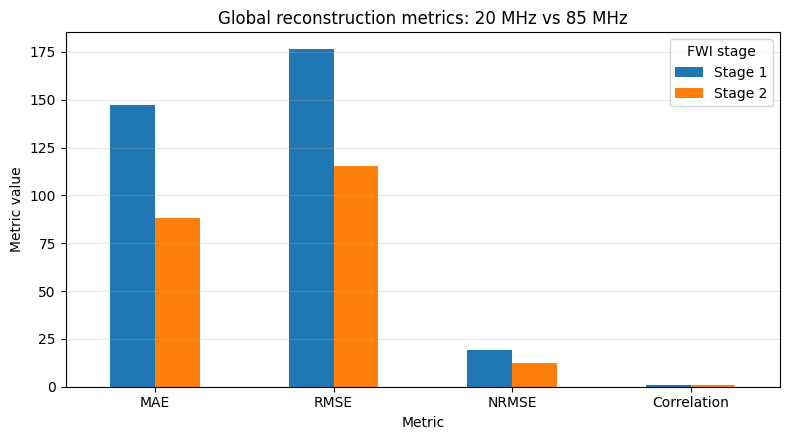

In [72]:
# ============================================================
# FIGURE 1: GLOBAL RECONSTRUCTION METRICS
# ============================================================

metrics_to_plot = ["MAE", "RMSE", "NRMSE", "Correlation"]

plot_df = global_df[
    global_df["Metric short name"].isin(metrics_to_plot)
].copy()

pivot_df = plot_df.pivot(
    index="Metric short name",
    columns="FWI stage",
    values="Value"
)

pivot_df = pivot_df.loc[metrics_to_plot]

ax = pivot_df.plot(
    kind="bar",
    figsize=(8, 4.5),
    rot=0
)

ax.set_title("Global reconstruction metrics: 20 MHz vs 85 MHz")
ax.set_ylabel("Metric value")
ax.set_xlabel("Metric")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="FWI stage")

plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, "global_metrics.png"),
    dpi=300
)
plt.show()

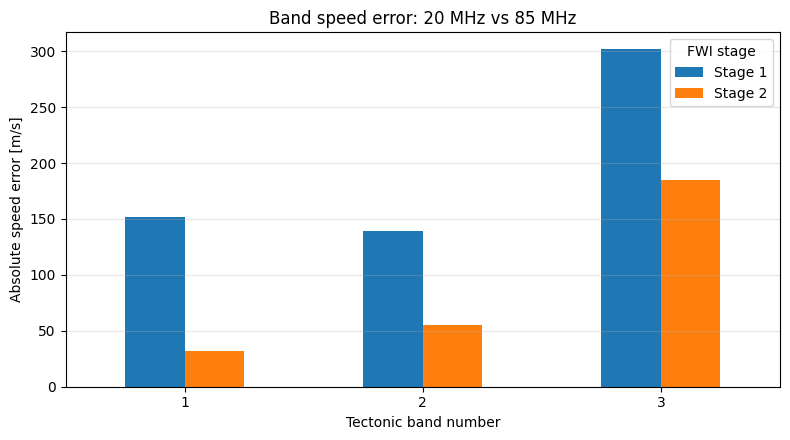

In [73]:
# ============================================================
# FIGURE 2: BAND SPEED ERROR
# ============================================================

speed_df = band_df.pivot(
    index="tectonic_band_number",
    columns="FWI stage",
    values="absolute_speed_error_m_per_s"
)

ax = speed_df.plot(
    kind="bar",
    figsize=(8, 4.5),
    rot=0
)

ax.set_title("Band speed error: 20 MHz vs 85 MHz")
ax.set_xlabel("Tectonic band number")
ax.set_ylabel("Absolute speed error [m/s]")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="FWI stage")

plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, "band_speed_errors.png"),
    dpi=300
)
plt.show()

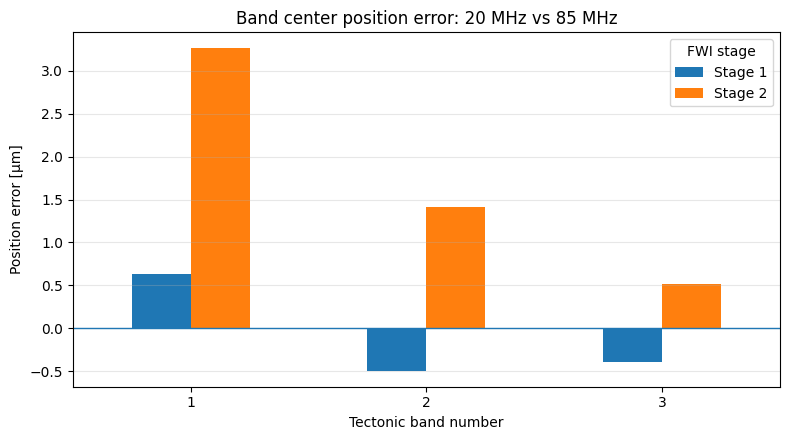

In [74]:
# ============================================================
# FIGURE 3: BAND POSITION ERROR
# ============================================================

position_df = band_df.pivot(
    index="tectonic_band_number",
    columns="FWI stage",
    values="position_error_micrometers"
)

ax = position_df.plot(
    kind="bar",
    figsize=(8, 4.5),
    rot=0
)

ax.axhline(0, linewidth=1)

ax.set_title("Band center position error: 20 MHz vs 85 MHz")
ax.set_xlabel("Tectonic band number")
ax.set_ylabel("Position error [µm]")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="FWI stage")

plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, "band_position_errors.png"),
    dpi=300
)
plt.show()

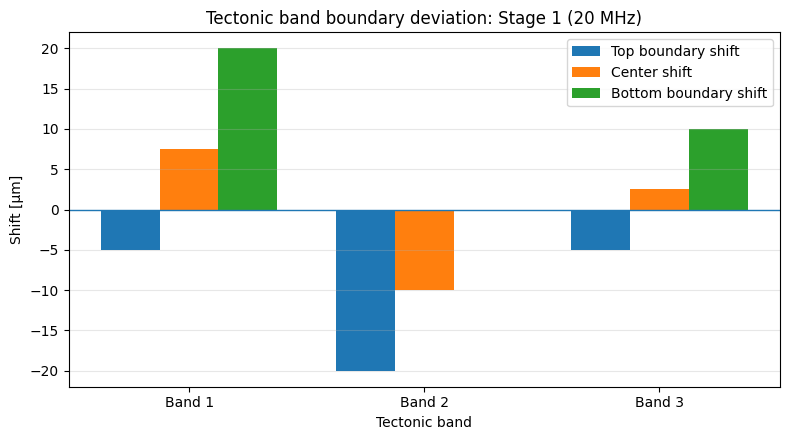

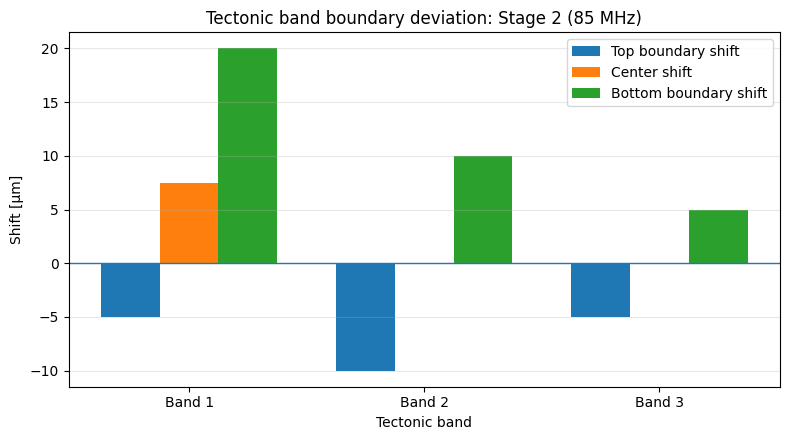

In [75]:
# ============================================================
# FIGURE 4: BOUNDARY DEVIATION
# ============================================================

for stage in ["Stage 1", "Stage 2"]:

    stage_df = boundary_df[
        boundary_df["FWI stage"] == stage
    ].copy()

    x = np.arange(len(stage_df))
    width = 0.25

    plt.figure(figsize=(8, 4.5))

    plt.bar(
        x - width,
        stage_df["top_boundary_shift_micrometers"],
        width,
        label="Top boundary shift"
    )

    plt.bar(
        x,
        stage_df["center_shift_micrometers"],
        width,
        label="Center shift"
    )

    plt.bar(
        x + width,
        stage_df["bottom_boundary_shift_micrometers"],
        width,
        label="Bottom boundary shift"
    )

    plt.axhline(0, linewidth=1)

    plt.xticks(
        x,
        [f"Band {int(b)}" for b in stage_df["tectonic_band_number"]]
    )

    plt.title(f"Tectonic band boundary deviation: {stage} ({'20 MHz' if stage == 'Stage 1' else '85 MHz'})")
    plt.xlabel("Tectonic band")
    plt.ylabel("Shift [µm]")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()

    plt.tight_layout()

    filename = stage.lower().replace(" ", "_") + "_boundary_deviation.png"

    plt.savefig(
        os.path.join(fig_dir, filename),
        dpi=300
    )

    plt.show()

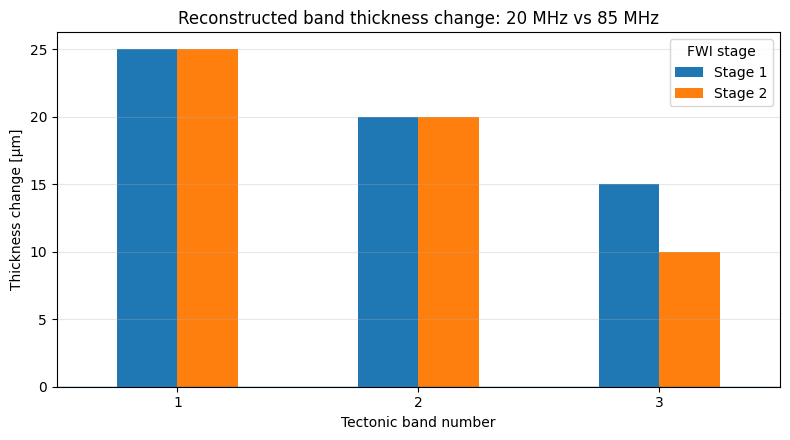

In [76]:
# ============================================================
# FIGURE 5: THICKNESS CHANGE
# ============================================================

thickness_df = boundary_df.pivot(
    index="tectonic_band_number",
    columns="FWI stage",
    values="thickness_change_micrometers"
)

ax = thickness_df.plot(
    kind="bar",
    figsize=(8, 4.5),
    rot=0
)

ax.axhline(0, linewidth=1)

ax.set_title("Reconstructed band thickness change: 20 MHz vs 85 MHz")
ax.set_xlabel("Tectonic band number")
ax.set_ylabel("Thickness change [µm]")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="FWI stage")

plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, "band_thickness_change.png"),
    dpi=300
)
plt.show()

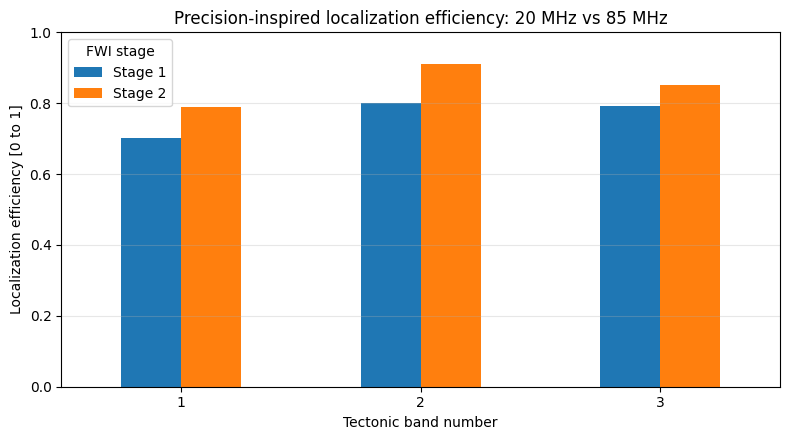

In [77]:
# ============================================================
# FIGURE 6: DETECTION EFFICIENCY
# ============================================================

eff_df = band_df.pivot(
    index="tectonic_band_number",
    columns="FWI stage",
    values="detection_efficiency_0_to_1"
)

ax = eff_df.plot(
    kind="bar",
    figsize=(8, 4.5),
    rot=0
)

ax.set_title("Precision-inspired localization efficiency: 20 MHz vs 85 MHz")
ax.set_xlabel("Tectonic band number")
ax.set_ylabel("Localization efficiency [0 to 1]")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="FWI stage")

plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, "detection_efficiency.png"),
    dpi=300
)
plt.show()

In [78]:
# ============================================================
# BACKGROUND / NON-BAND SILICON EVALUATION
# ============================================================
# Purpose:
#   Evaluate the part of the silicon sample that is NOT inside
#   any true tectonic band.
#
# Why this matters:
#   The band metrics show recovery inside the true irregular bands.
#   This background analysis checks whether the reconstruction creates
#   artificial velocity structure where the true model should remain
#   homogeneous silicon.
#
# Output:
#   TABLE_background_non_band_silicon_metrics_READABLE.csv
# ============================================================

import os
import numpy as np
import pandas as pd

os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# Build union mask of all true tectonic bands
# ------------------------------------------------------------

all_true_band_mask = np.zeros(true_sos_np.shape, dtype=bool)

for band_number, band_mask in true_band_masks.items():
    all_true_band_mask = all_true_band_mask | band_mask

# ------------------------------------------------------------
# Define evaluation regions
# ------------------------------------------------------------

# Silicon area inside inversion mask, excluding all true tectonic bands
background_non_band_mask = (
    inside_silicon
    & inside_inversion_mask
    & (~all_true_band_mask)
)

# True tectonic band region inside inversion mask
all_band_region_mask = (
    inside_silicon
    & inside_inversion_mask
    & all_true_band_mask
)

print("Background non-band pixels:", np.sum(background_non_band_mask))
print("True band pixels:", np.sum(all_band_region_mask))
print("Total evaluated silicon pixels:", np.sum(background_non_band_mask) + np.sum(all_band_region_mask))

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def compute_background_metrics(stage_name, stage_description, sos_map, update_map):

    true_values = true_sos_np[background_non_band_mask]
    reconstructed_values = sos_map[background_non_band_mask]
    update_values = update_map[background_non_band_mask]

    error = reconstructed_values - true_values

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    bias = np.mean(error)

    mean_abs_update = np.mean(np.abs(update_values))
    median_abs_update = np.median(np.abs(update_values))
    max_abs_update = np.max(np.abs(update_values))

    positive_update_energy = np.mean(np.maximum(update_values, 0.0))
    negative_update_energy = np.mean(np.maximum(-update_values, 0.0))

    # Fraction of background pixels with a suspiciously large update.
    # Thresholds are absolute velocity-update thresholds.
    thresholds = [25, 50, 100, 150, 200]

    rows = []

    base_row = {
        "region": "silicon_background_outside_true_bands",
        "FWI stage": stage_name,
        "Stage description": stage_description,
        "number_of_pixels": int(np.sum(background_non_band_mask)),

        "MAE_background_m_per_s": mae,
        "RMSE_background_m_per_s": rmse,
        "Bias_background_m_per_s": bias,

        "mean_absolute_velocity_update_background_m_per_s": mean_abs_update,
        "median_absolute_velocity_update_background_m_per_s": median_abs_update,
        "max_absolute_velocity_update_background_m_per_s": max_abs_update,

        "mean_positive_update_background_m_per_s": positive_update_energy,
        "mean_negative_update_background_m_per_s": negative_update_energy,
    }

    for threshold in thresholds:
        fraction_above = np.mean(np.abs(update_values) >= threshold)

        base_row[
            f"fraction_background_pixels_abs_update_ge_{threshold}_m_per_s"
        ] = fraction_above

    rows.append(base_row)

    return rows


# ------------------------------------------------------------
# Compute Stage 1 and Stage 2 background metrics
# ------------------------------------------------------------

background_rows = []

background_rows.extend(
    compute_background_metrics(
        stage_name="Stage 1",
        stage_description="20 MHz low-frequency FWI reconstruction",
        sos_map=stage1_sos_np,
        update_map=stage1_update_np,
    )
)

background_rows.extend(
    compute_background_metrics(
        stage_name="Stage 2",
        stage_description="85 MHz high-frequency FWI reconstruction initialized from Stage 1",
        sos_map=stage2_sos_np,
        update_map=stage2_update_np,
    )
)

background_metrics_df = pd.DataFrame(background_rows)

# ------------------------------------------------------------
# Add improvement row
# ------------------------------------------------------------

stage1_row = background_metrics_df[
    background_metrics_df["FWI stage"] == "Stage 1"
].iloc[0]

stage2_row = background_metrics_df[
    background_metrics_df["FWI stage"] == "Stage 2"
].iloc[0]

improvement_row = {
    "region": "silicon_background_outside_true_bands",
    "FWI stage": "Stage 2 minus Stage 1",
    "Stage description": "Positive improvement means background artifact/error decreased",
    "number_of_pixels": int(np.sum(background_non_band_mask)),

    "MAE_background_m_per_s": (
        stage1_row["MAE_background_m_per_s"]
        - stage2_row["MAE_background_m_per_s"]
    ),
    "RMSE_background_m_per_s": (
        stage1_row["RMSE_background_m_per_s"]
        - stage2_row["RMSE_background_m_per_s"]
    ),
    "Bias_background_m_per_s": (
        abs(stage1_row["Bias_background_m_per_s"])
        - abs(stage2_row["Bias_background_m_per_s"])
    ),
    "mean_absolute_velocity_update_background_m_per_s": (
        stage1_row["mean_absolute_velocity_update_background_m_per_s"]
        - stage2_row["mean_absolute_velocity_update_background_m_per_s"]
    ),
    "median_absolute_velocity_update_background_m_per_s": (
        stage1_row["median_absolute_velocity_update_background_m_per_s"]
        - stage2_row["median_absolute_velocity_update_background_m_per_s"]
    ),
    "max_absolute_velocity_update_background_m_per_s": (
        stage1_row["max_absolute_velocity_update_background_m_per_s"]
        - stage2_row["max_absolute_velocity_update_background_m_per_s"]
    ),
    "mean_positive_update_background_m_per_s": (
        stage1_row["mean_positive_update_background_m_per_s"]
        - stage2_row["mean_positive_update_background_m_per_s"]
    ),
    "mean_negative_update_background_m_per_s": (
        stage1_row["mean_negative_update_background_m_per_s"]
        - stage2_row["mean_negative_update_background_m_per_s"]
    ),
}

for threshold in [25, 50, 100, 150, 200]:
    col = f"fraction_background_pixels_abs_update_ge_{threshold}_m_per_s"

    improvement_row[col] = (
        stage1_row[col]
        - stage2_row[col]
    )

background_metrics_df = pd.concat(
    [
        background_metrics_df,
        pd.DataFrame([improvement_row])
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

background_metrics_csv = os.path.join(
    output_dir,
    "TABLE_background_non_band_silicon_metrics_READABLE.csv"
)

background_metrics_df.to_csv(background_metrics_csv, index=False)

display(background_metrics_df)

print("Saved background / non-band silicon metrics CSV:")
print(background_metrics_csv)

Background non-band pixels: 3234
True band pixels: 1342
Total evaluated silicon pixels: 4576


,region,FWI stage,Stage description,number_of_pixels,MAE_background_m_per_s,RMSE_background_m_per_s,Bias_background_m_per_s,mean_absolute_velocity_update_background_m_per_s,median_absolute_velocity_update_background_m_per_s,max_absolute_velocity_update_background_m_per_s,mean_positive_update_background_m_per_s,mean_negative_update_background_m_per_s,fraction_background_pixels_abs_update_ge_25_m_per_s,fraction_background_pixels_abs_update_ge_50_m_per_s,fraction_background_pixels_abs_update_ge_100_m_per_s,fraction_background_pixels_abs_update_ge_150_m_per_s,fraction_background_pixels_abs_update_ge_200_m_per_s
0,silicon_background_outside_true_bands,Stage 1,20 MHz low-frequency FWI reconstruction,3234,122.777962,150.796570,48.987766,122.777962,104.244629,416.672852,85.882866,36.895096,0.897959,0.768707,0.519790,0.32282,0.190785
1,silicon_background_outside_true_bands,Stage 2,85 MHz high-frequency FWI reconstruction initi...,3234,79.831169,102.491768,28.785988,79.831169,65.997559,485.123047,54.308578,25.522593,0.811998,0.617192,0.290662,0.12616,0.053803
2,silicon_background_outside_true_bands,Stage 2 minus Stage 1,Positive improvement means background artifact...,3234,42.946793,48.304802,20.201778,42.946793,38.247070,-68.450195,31.574287,11.372503,0.085962,0.151515,0.229128,0.19666,0.136982


Saved background / non-band silicon metrics CSV:
fwi_20MHz_to_85MHz_3bands_realistic_tectonic_results/TABLE_background_non_band_silicon_metrics_READABLE.csv
